# **Missing Value Analysis_Continue**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/SARCOPENIA_PROJECT/sarcopenia-data-set_columns_corrected_1.xlsx")

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Name,0
Order,0
Gender,0
Age,0
Weight,0
Height,0
Waist,0
Hip,0
Smoking,0


In [ ]:
df.CST.max()

18.75

In [ ]:
df.MMSE.min()

24

In [ ]:
df.Height.max()

182.5

In [ ]:
df.drop("Unnamed: 0",axis=1,inplace=True)

# **Data Type Conversion**

In [ ]:
df.dtypes

,0
Name,object
Order,int64
Gender,object
Age,float64
Weight,float64
Height,float64
Waist,float64
Hip,float64
Smoking,int64
Smoking_packet_year,float64


In [ ]:
df.Dyslipidemia_duration.dtype

dtype('int64')

In [ ]:
df["Dyslipidemia_duration"] = df["Dyslipidemia_duration"].astype(float)

In [ ]:
df["Dyslipidemia_duration"].dtype

dtype('float64')

In [ ]:
df["KAH_Duration"] = df["KAH_Duration"].astype(float)

In [ ]:
df.OP.value_counts()

,count
OP,
0,3335
1,1680
,1


In [ ]:
df["OP"] = pd.to_numeric(df["OP"], errors='coerce')

In [ ]:
print(df["OP"].isnull().sum())

1


In [ ]:
df.fillna({"df.OP": 0}, inplace=True)

In [ ]:
df["OP"] = df["OP"].astype('Int64')

In [ ]:
df.OP.dtype

Int64Dtype()

In [ ]:
df.OP.value_counts()

,count
OP,
0,3335
1,1680


In [ ]:
df.Smoking_packet_year.isnull().sum()

np.int64(2)

In [ ]:
df.loc[(df.Smoking_packet_year.isnull(),"Smoking_packet_year")] = df.Smoking_packet_year.median()

In [ ]:
df.Smoking_packet_year.isnull().sum()

np.int64(0)

In [ ]:
df.rename({"Smoking_packet_year":"Smoking_packet_per_year"},axis=1,inplace=True)

In [ ]:
df.columns

Index(['Name', 'Order', 'Gender', 'Age', 'Weight', 'Height', 'Waist', 'Hip',
       'Smoking', 'Smoking_packet_per_year', 'Alcohol', 'DM_Type2',
       'DM_Type2_Duration', 'Insulin', 'DM_Type2_Drug', 'DM_Type2_Drug_Usage',
       'Dyslipidemia', 'Dyslipidemia_duration', 'KAH', 'KAH_Duration',
       'Hipotiroidi', 'Asthma', 'COPD', 'OP', 'HT', 'Duration_of_HT', 'N_HT',
       'HT_drugs', 'HT_Drug_Usage', 'Duration_of_1HT', 'Education', 'Job',
       'Status', 'Work_Status', 'Exercise', 'AT', 'CST', 'Gait_Speed',
       'Grip_Str', 'STAR', 'BMI', 'MMSE', 'Sarcopenia'],
      dtype='object')

# **Univariate Analysis**

In [ ]:
df.Age.describe()

,Age
count,5016.000000
mean,61.994816
std,9.689233
min,42.000000
25%,54.000000
50%,62.000000
75%,69.000000
max,91.500000


<Axes: >

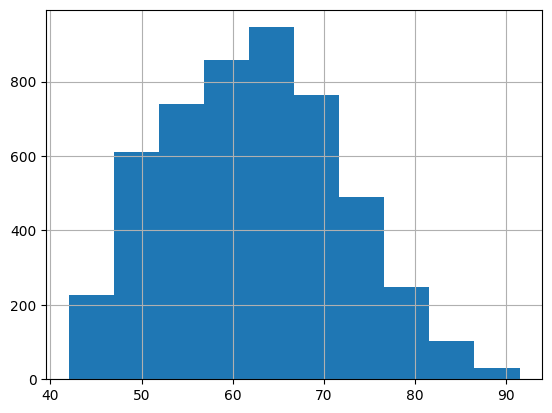

In [ ]:
df["Age"].hist()

In [ ]:
def boxplot(column):
  plt.figure(figsize=(8, 6)) # Set the figure size
  # Create a boxplot for the distribution of the 'Age' column
  sns.boxplot(y=df['Age'], palette='viridis')

  # --- 3. Customize the Plot (Optional) ---
  plt.title('Box Plot of Age Distribution (Seaborn)', fontsize=16)
  plt.ylabel('Age', fontsize=12)
  plt.xlabel('Distribution', fontsize=12) # Modified label for clarity

  # --- 4. Display the Plot ---
  plt.show()

<ipython-input-42-8fe4ef999f87>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['Age'], palette='viridis')


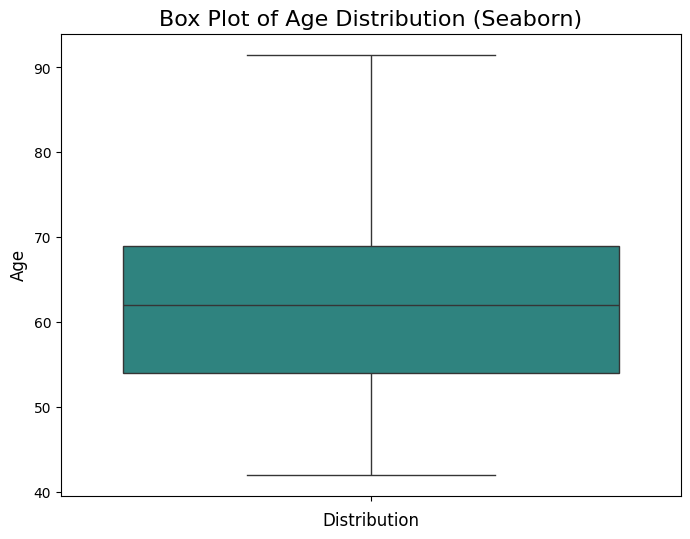

In [ ]:
boxplot(df.Age)

**Numeric verilerin histogram ve boxplot grafiklerini birlikte yanyana göstermek amacıyla "histog_boxplot" fonksiyonu kullanıldı.**

In [ ]:
def histog_boxplot(column):
  # Figür ve alt grafikleri oluşturalım
  # 1 satır, 2 sütunlu bir düzen oluştururuz
  # figsize, tüm figürün boyutunu (genişlik, yükseklik) piksel cinsinden ayarlar
  fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 satır, 2 sütun

  # --- Birinci Alt Grafik: Histogram ---
  # axes[0] ilk alt grafiği temsil eder (sol taraf)
  sns.histplot(column, kde=True, ax=axes[0], color='skyblue') # kde=True yoğunluk tahmini çizgisi ekler
  # Concatenate the column name and description into a single string for the title
  axes[0].set_title(f'{column.name} (Histogram)', fontsize=14)
  axes[0].set_xlabel('Değerler', fontsize=12)
  axes[0].set_ylabel('Frekans', fontsize=12)
  axes[0].grid(axis='y', linestyle='--', alpha=0.7)


  # --- İkinci Alt Grafik: Box Plot ---
  # axes[1] ikinci alt grafiği temsil eder (sağ taraf)
  sns.boxplot(y=column, ax=axes[1], color='lightcoral') # Sadece tek bir sütun olduğu için 'y' eksenine atarız
  # Concatenate the column name and description into a single string for the title
  axes[1].set_title(f'{column.name} (Box Plot)', fontsize=14)
  axes[1].set_ylabel('Değerler', fontsize=12)
  axes[1].grid(axis='y', linestyle='--', alpha=0.7)


  # Grafiklerin düzenini optimize edelim ve çakışmaları önleyelim
  plt.tight_layout()

  # Grafiği gösterelim
  plt.show()

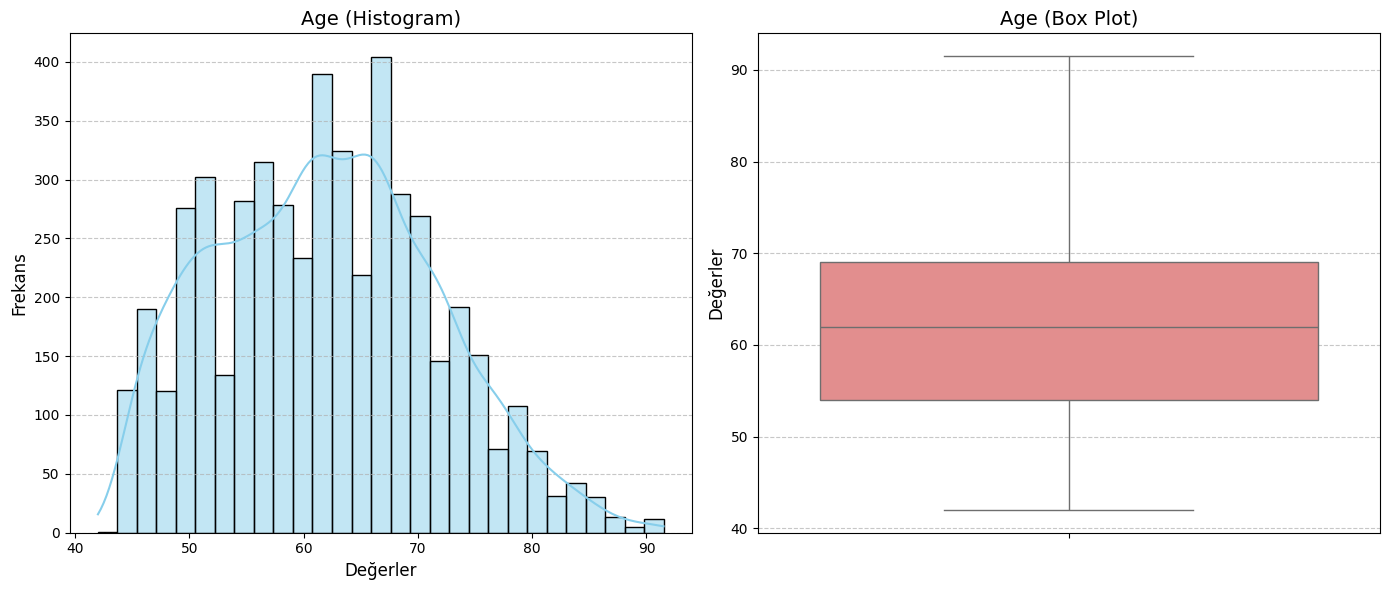

In [ ]:
histog_boxplot(df["Age"])

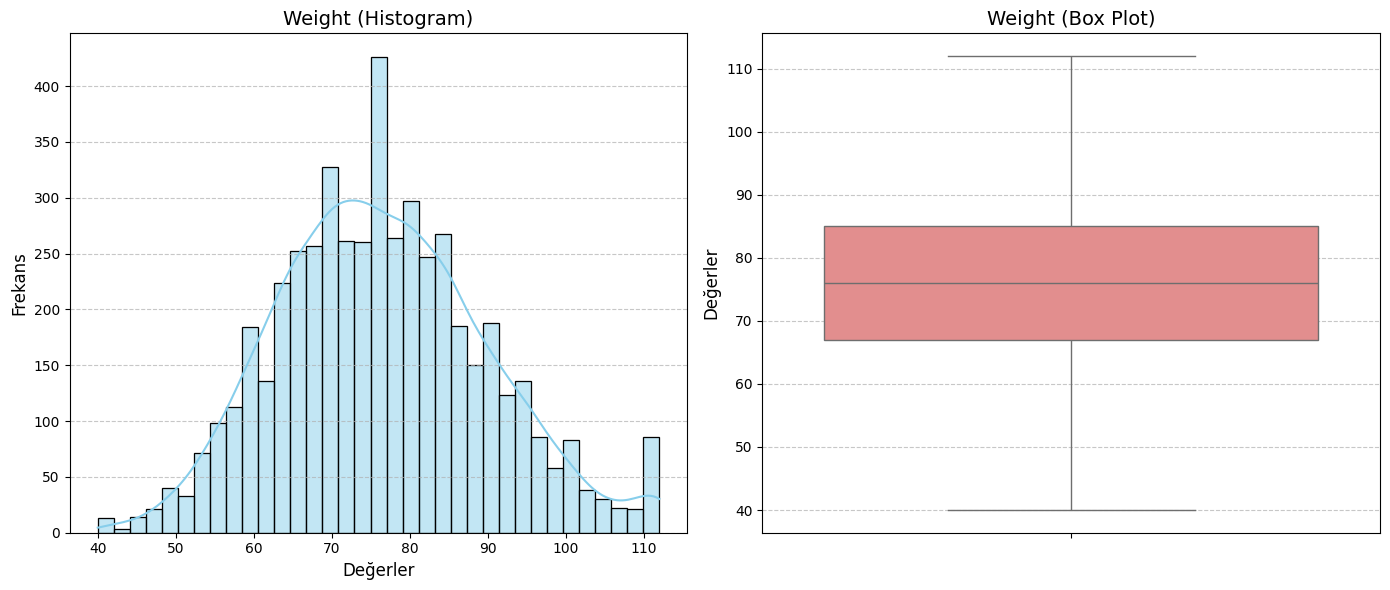

In [ ]:
histog_boxplot(df["Weight"])

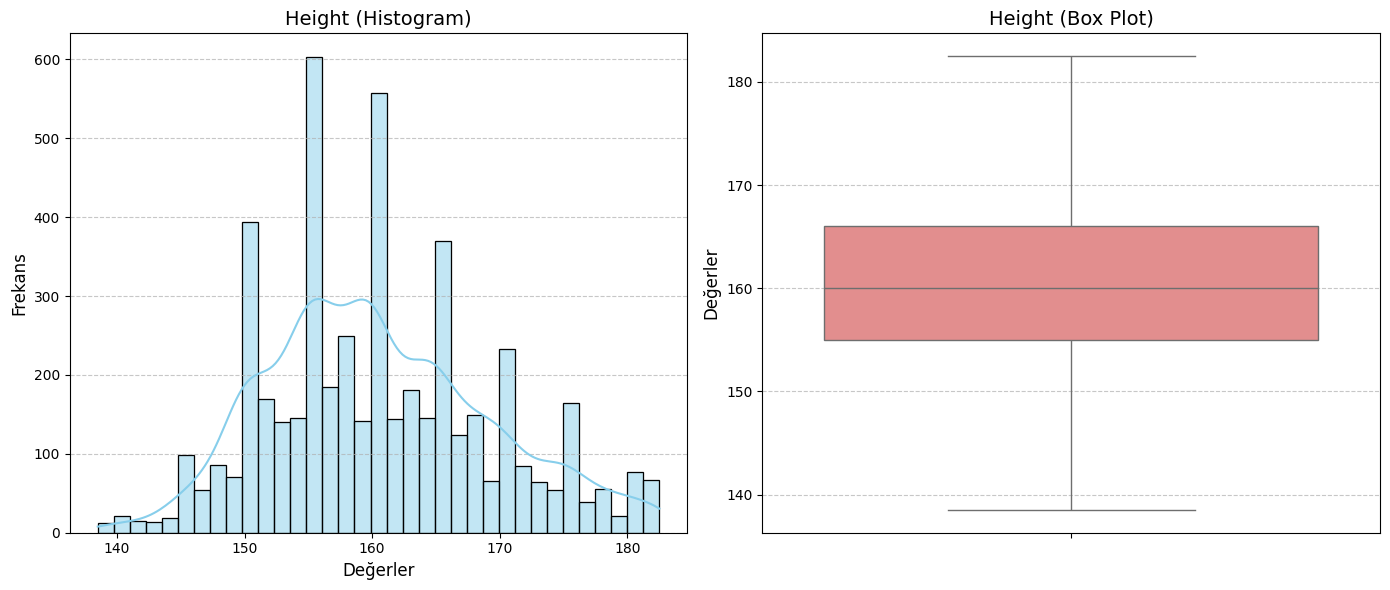

In [ ]:
histog_boxplot(df["Height"])

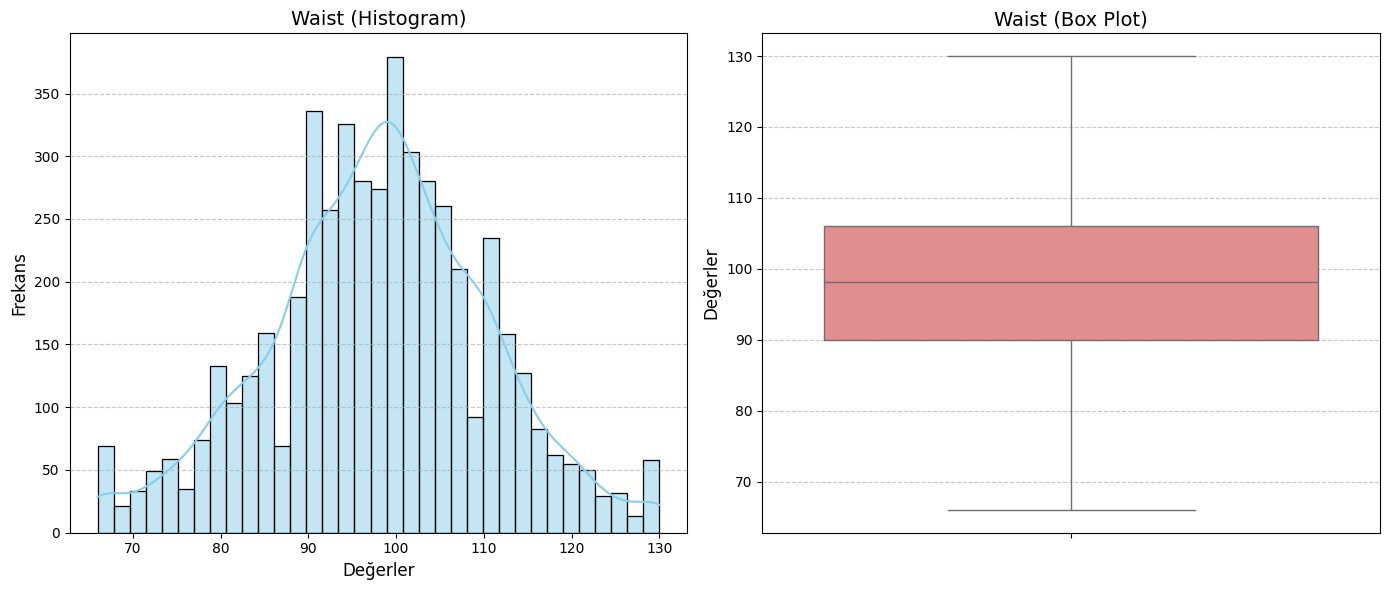

In [ ]:
histog_boxplot(df.Waist)

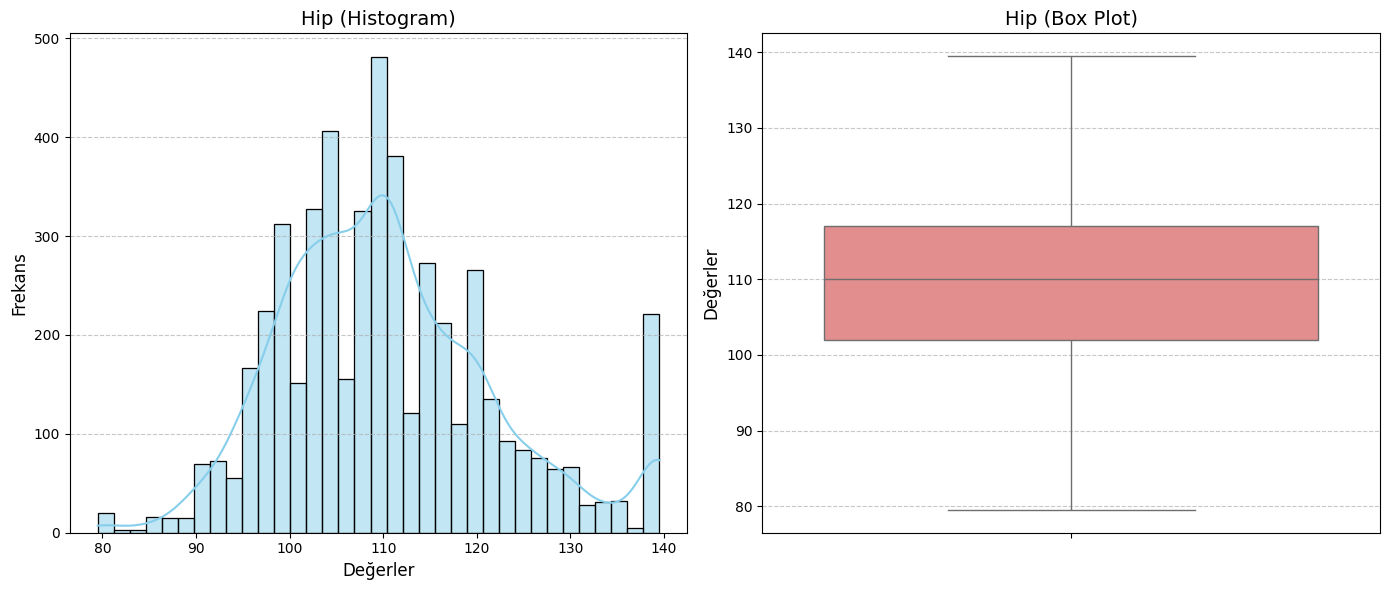

In [ ]:
histog_boxplot(df.Hip)

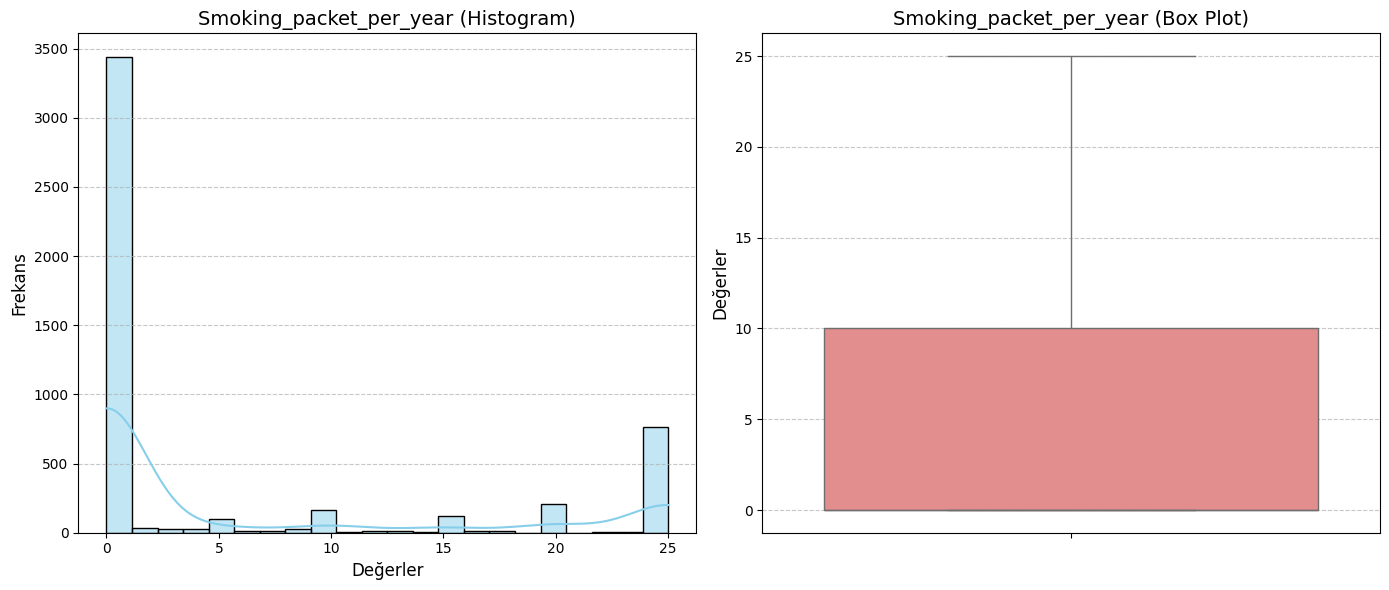

In [ ]:
histog_boxplot(df.Smoking_packet_per_year)

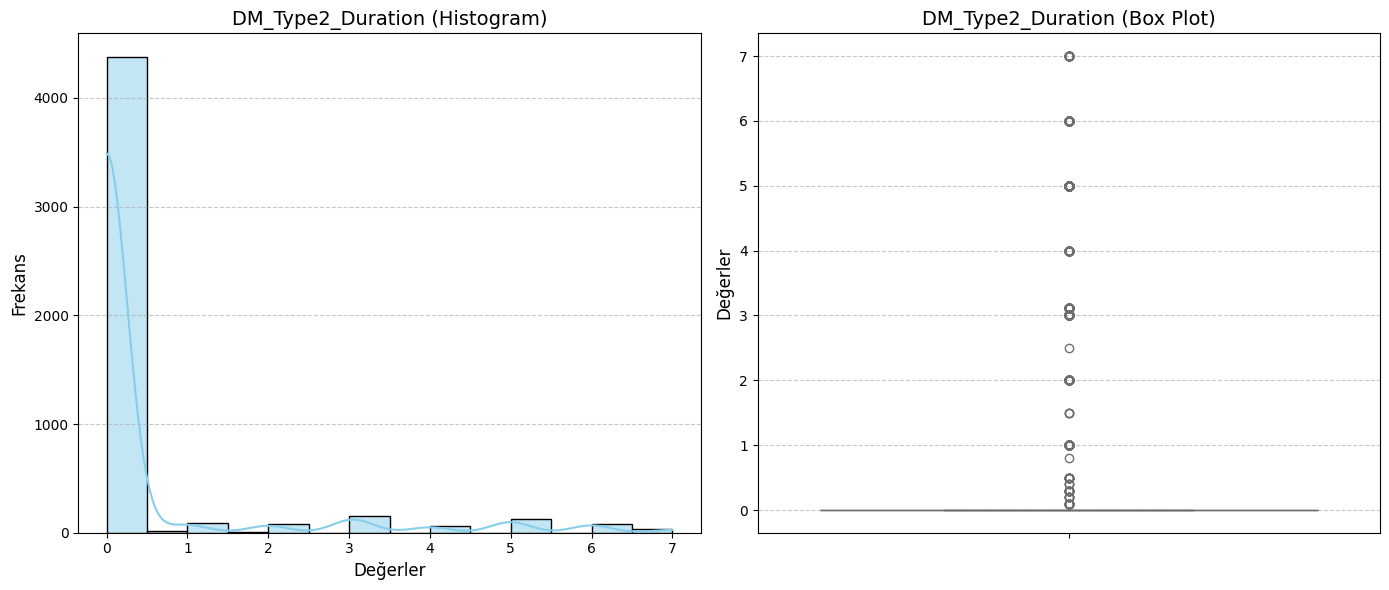

In [ ]:
histog_boxplot(df.DM_Type2_Duration)

In [ ]:
df.DM_Type2_Duration.describe()

,DM_Type2_Duration
count,5016.000000
mean,0.464094
std,1.370490
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.000000


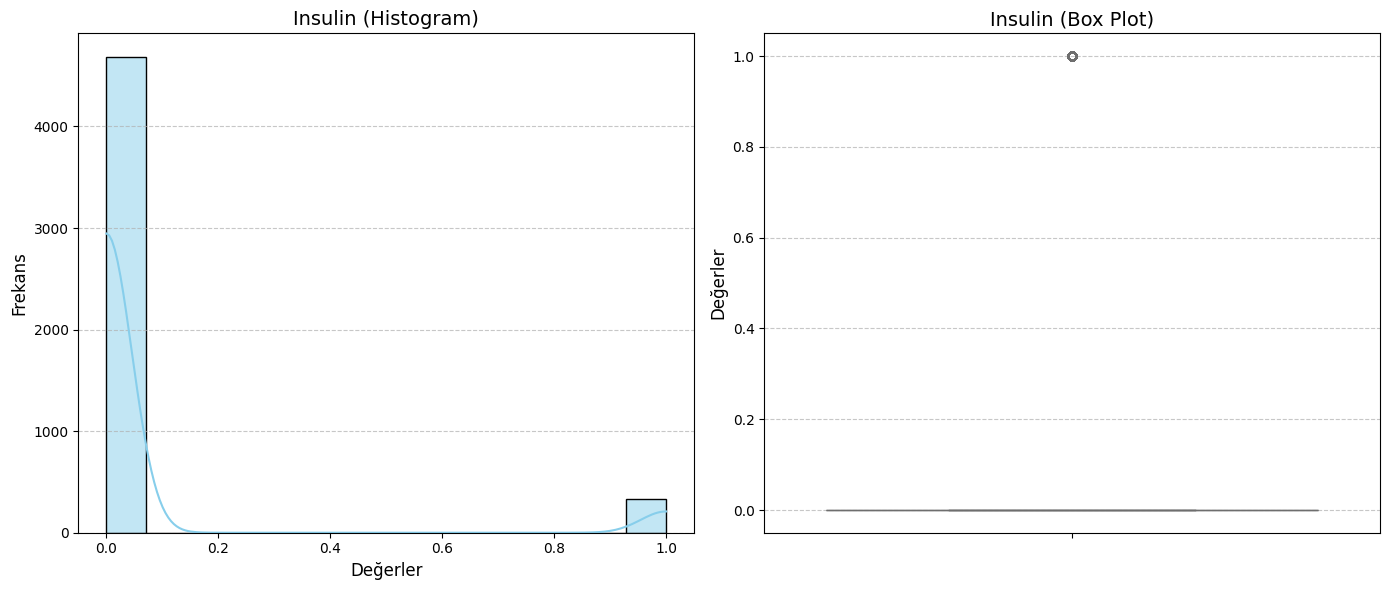

In [ ]:
histog_boxplot(df.Insulin)

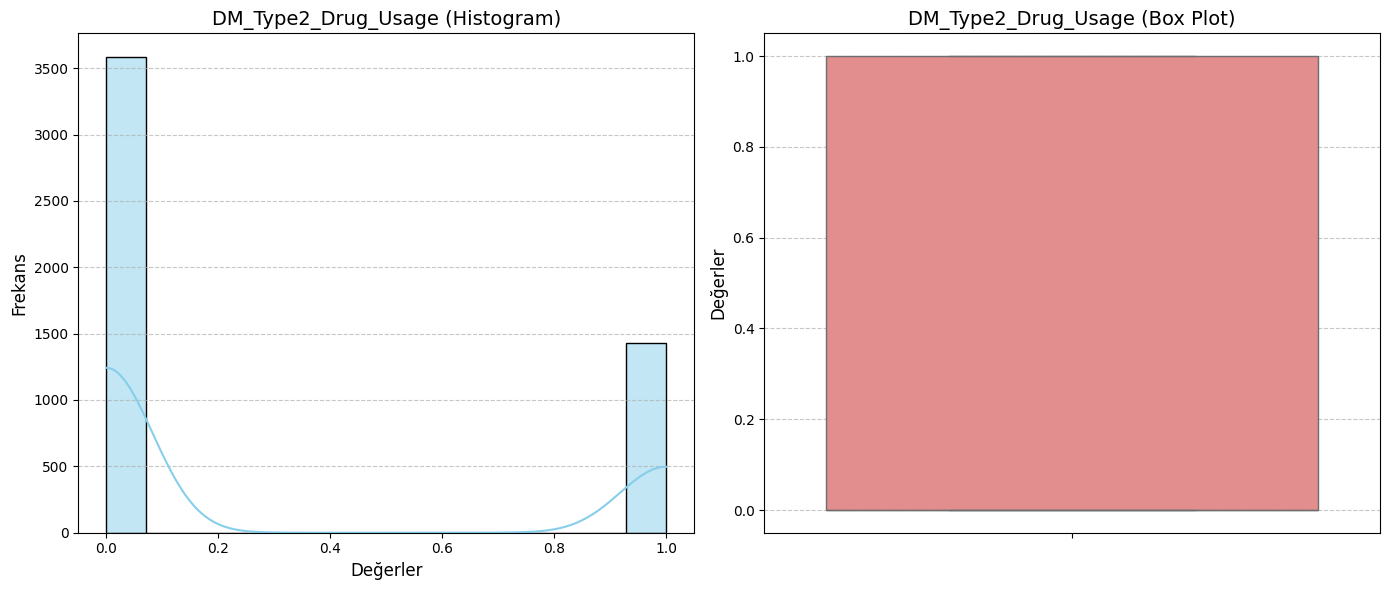

In [ ]:
histog_boxplot(df.DM_Type2_Drug_Usage)

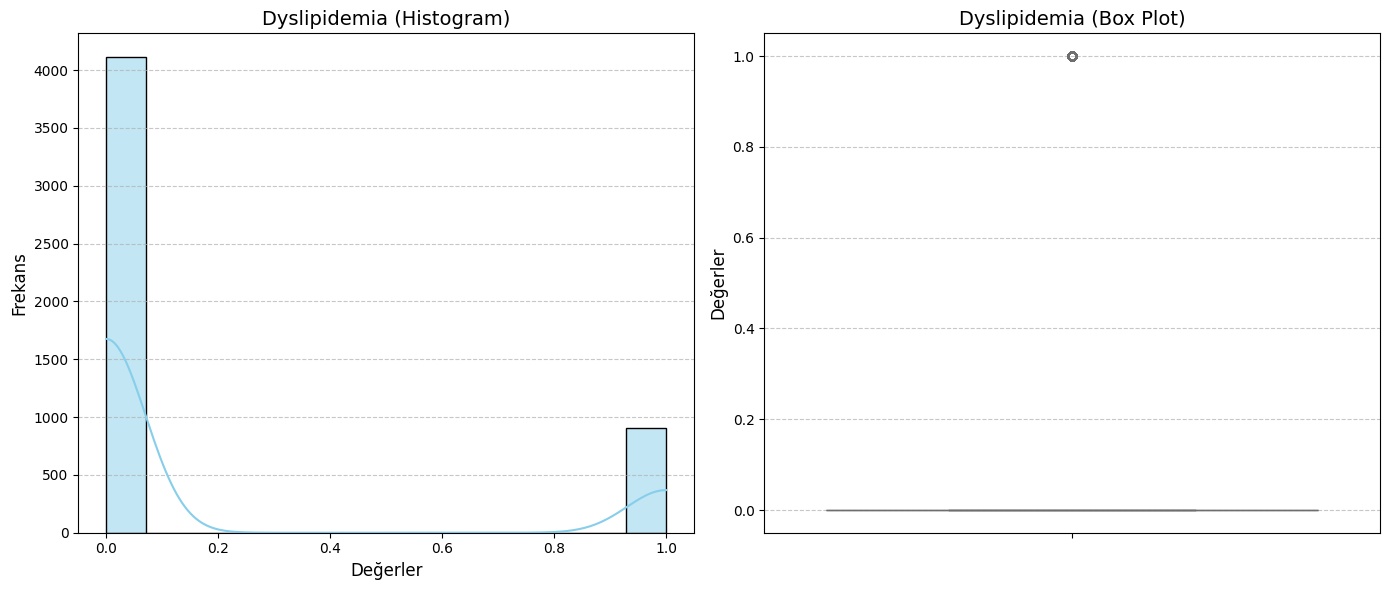

In [ ]:
histog_boxplot(df.Dyslipidemia)

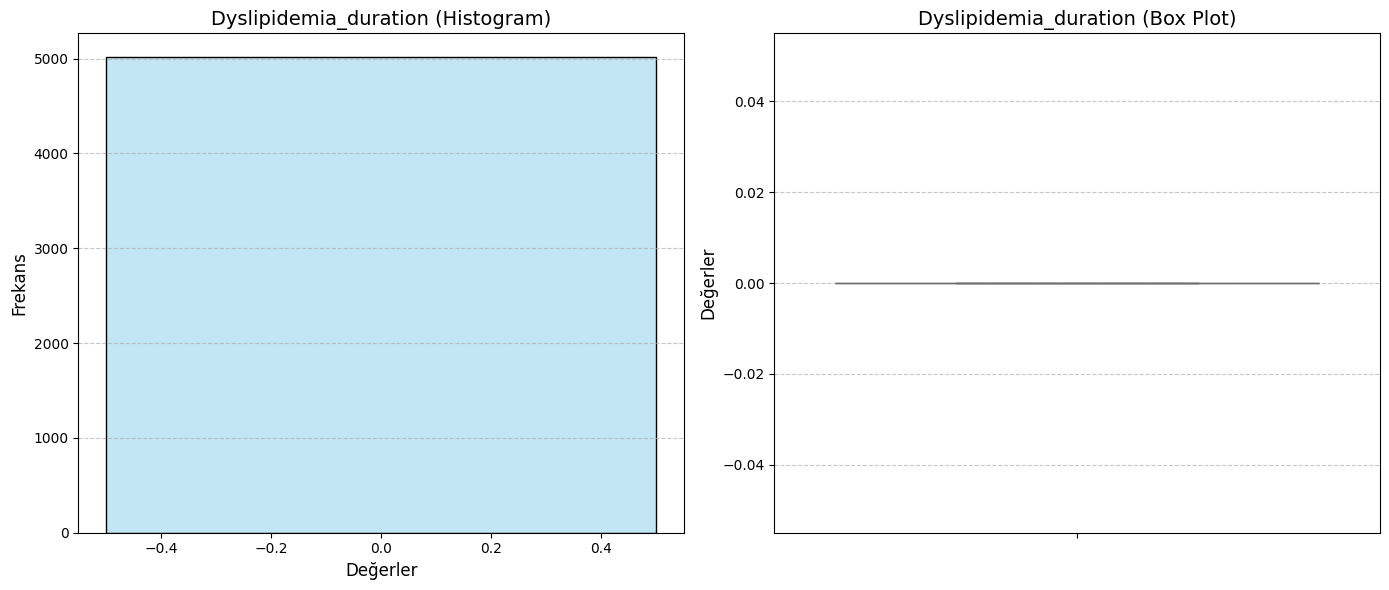

In [ ]:
histog_boxplot(df.Dyslipidemia_duration)

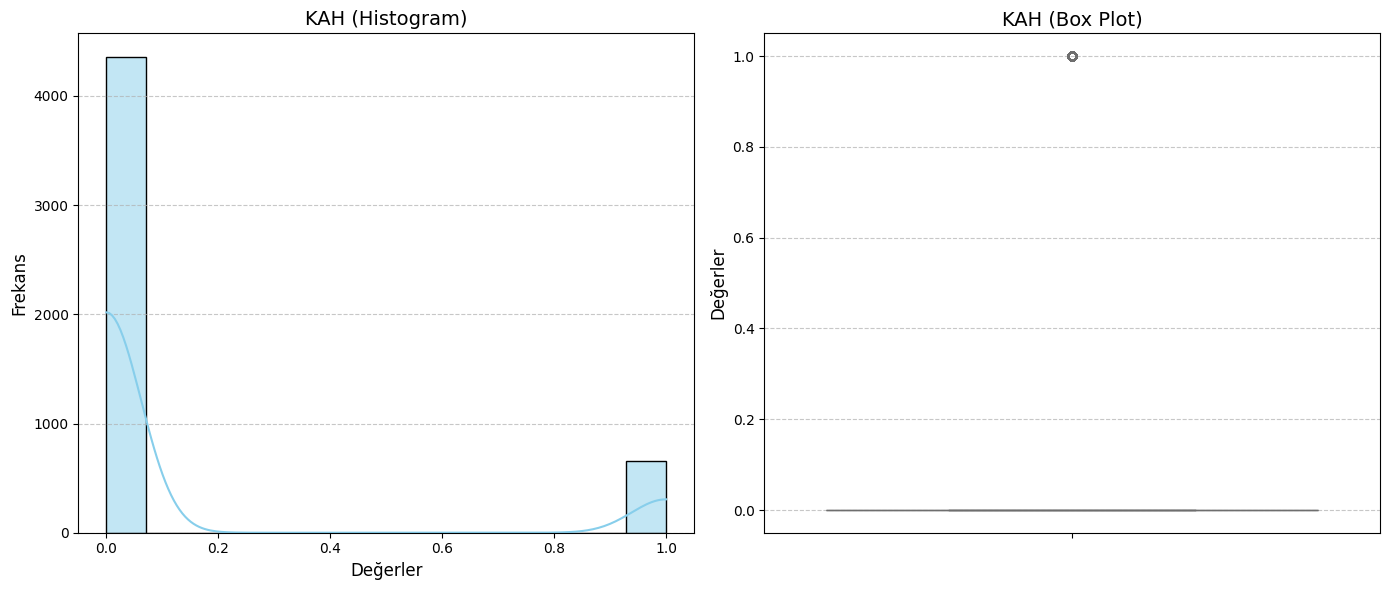

In [ ]:
histog_boxplot(df.KAH)

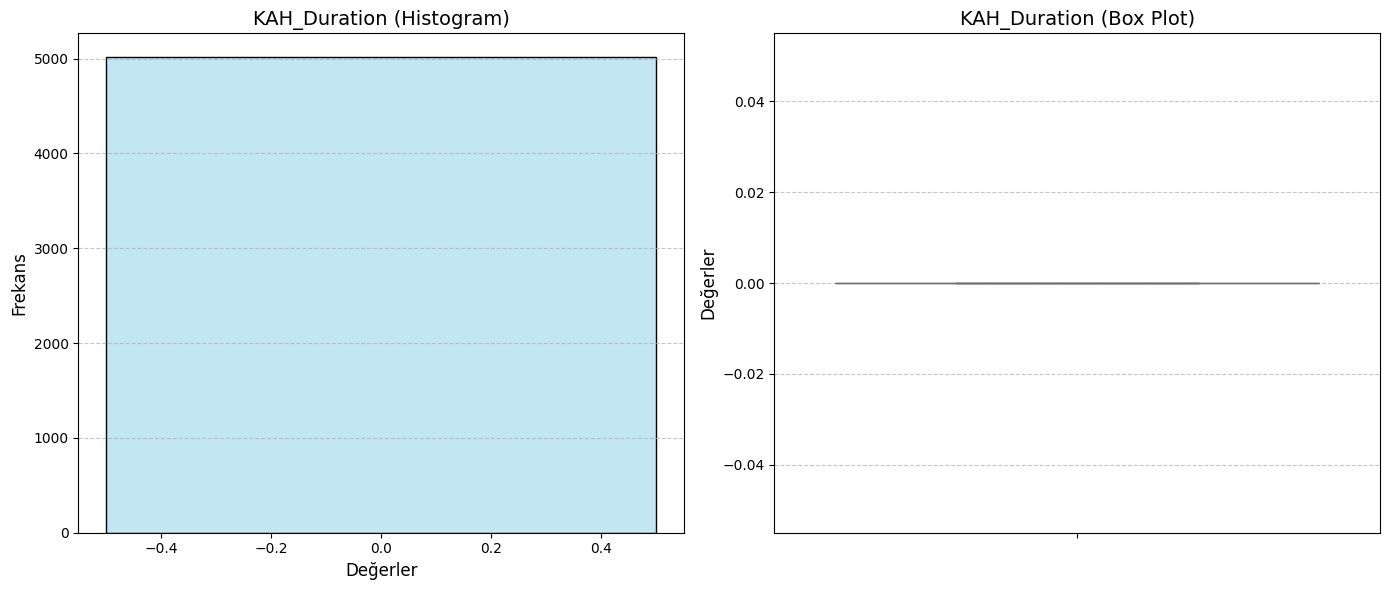

In [ ]:
histog_boxplot(df.KAH_Duration)

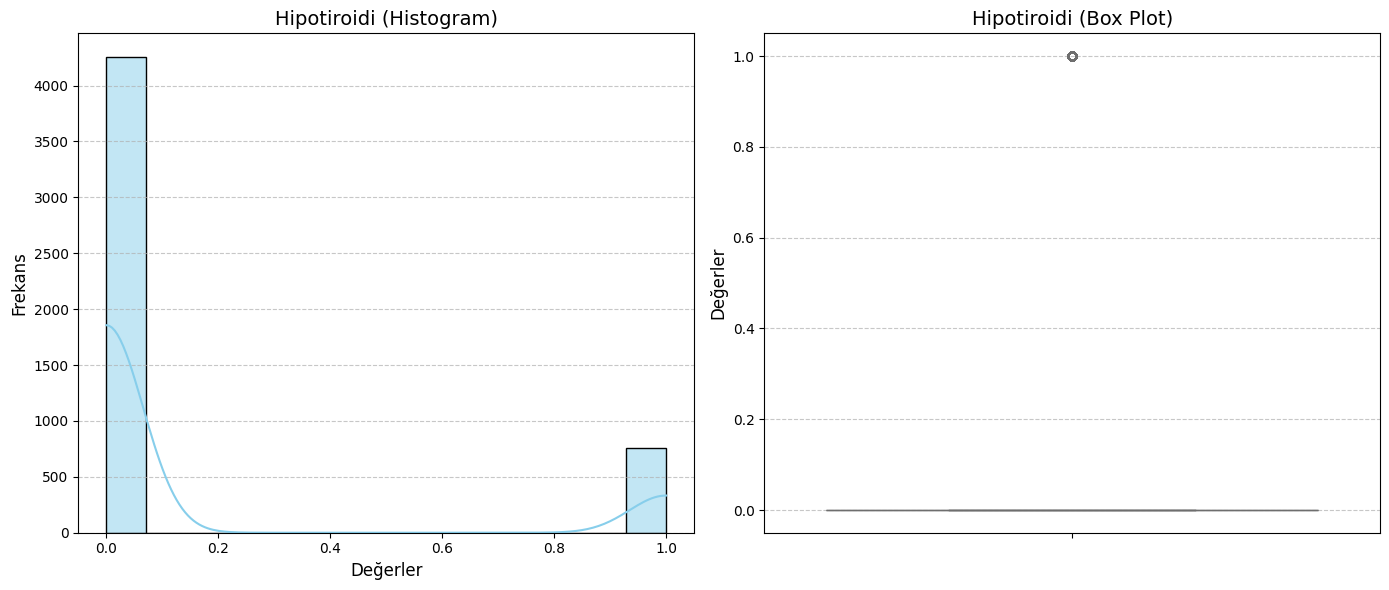

In [ ]:
histog_boxplot(df.Hipotiroidi)

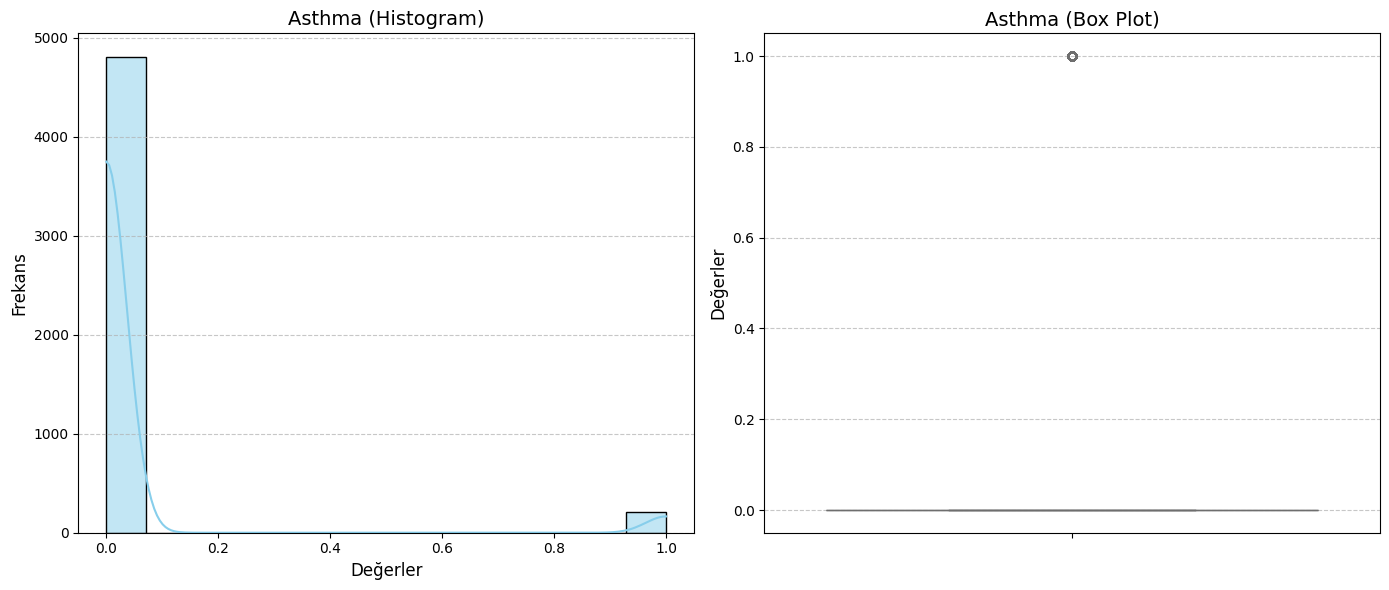

In [ ]:
histog_boxplot(df.Asthma)

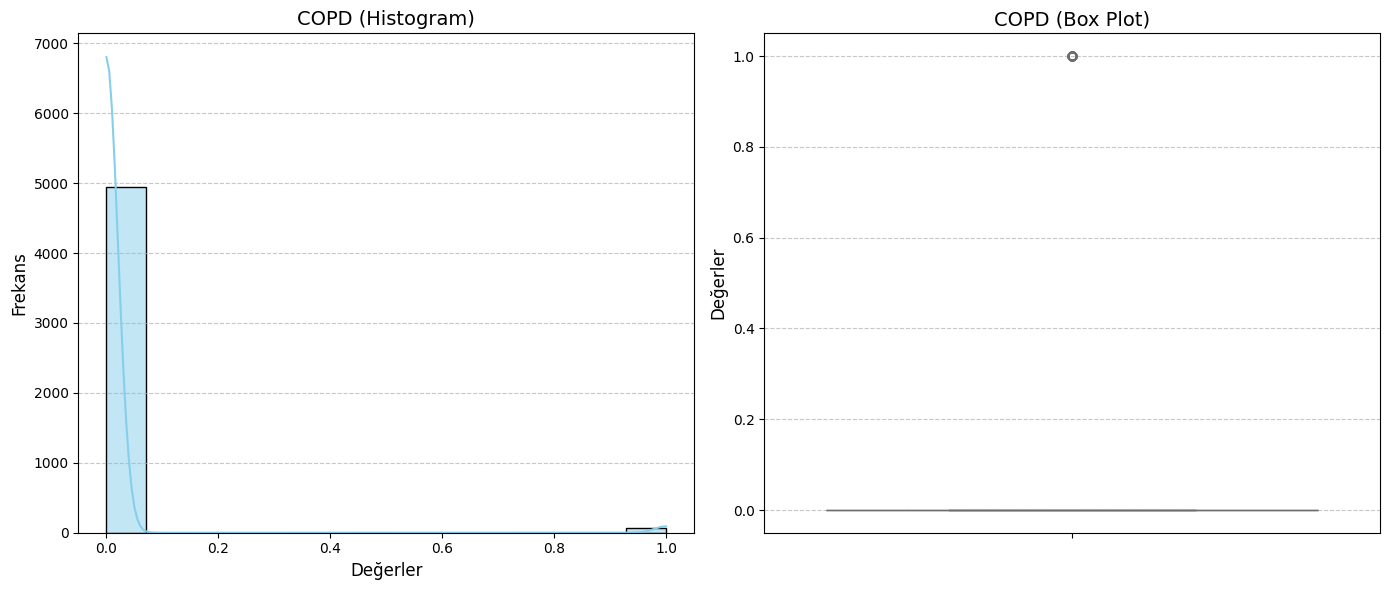

In [ ]:
histog_boxplot(df.COPD)

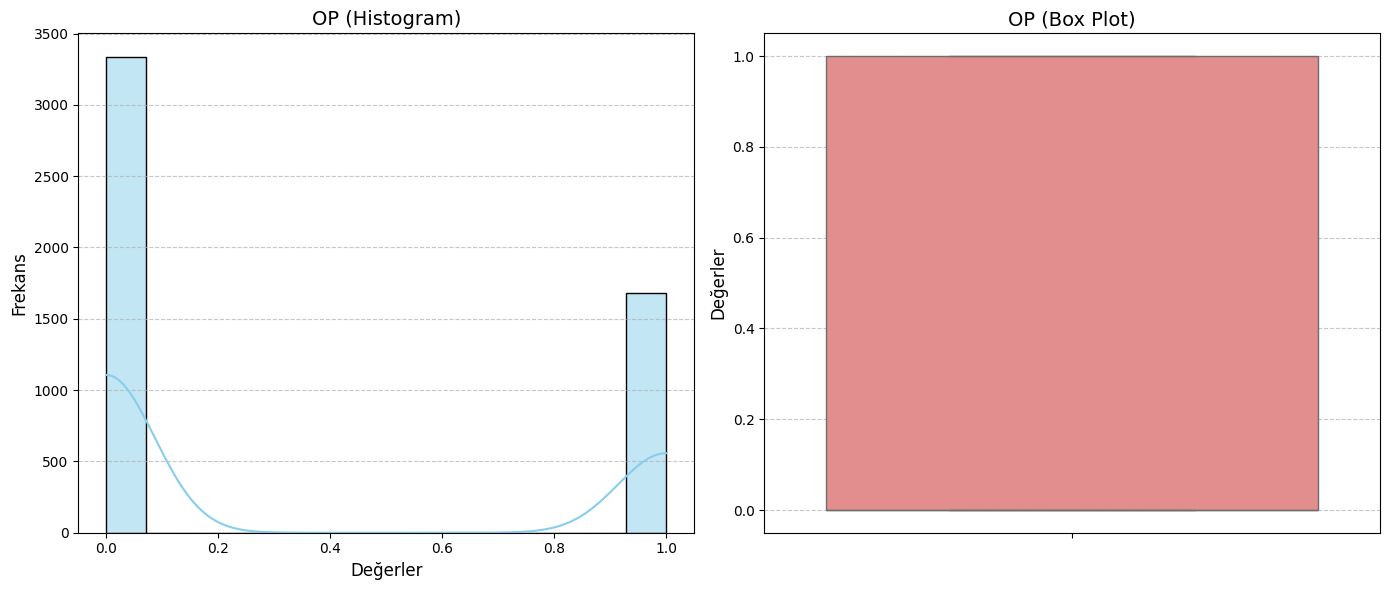

In [ ]:
histog_boxplot(df.OP)

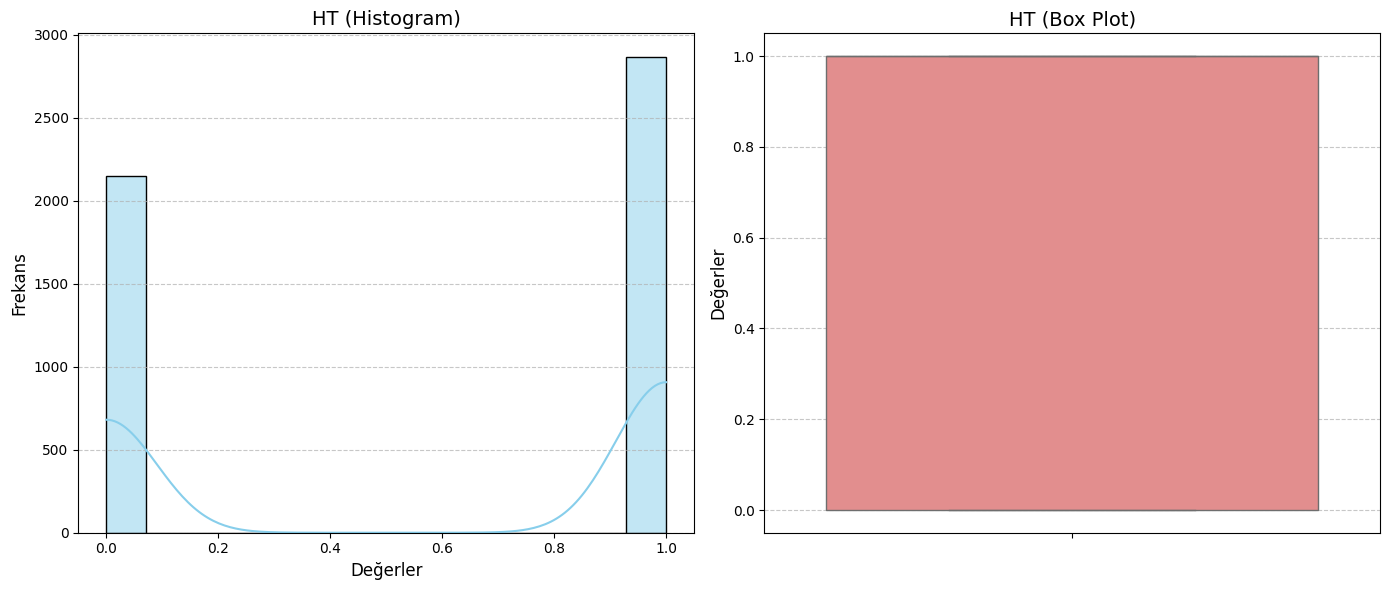

In [ ]:
histog_boxplot(df.HT)

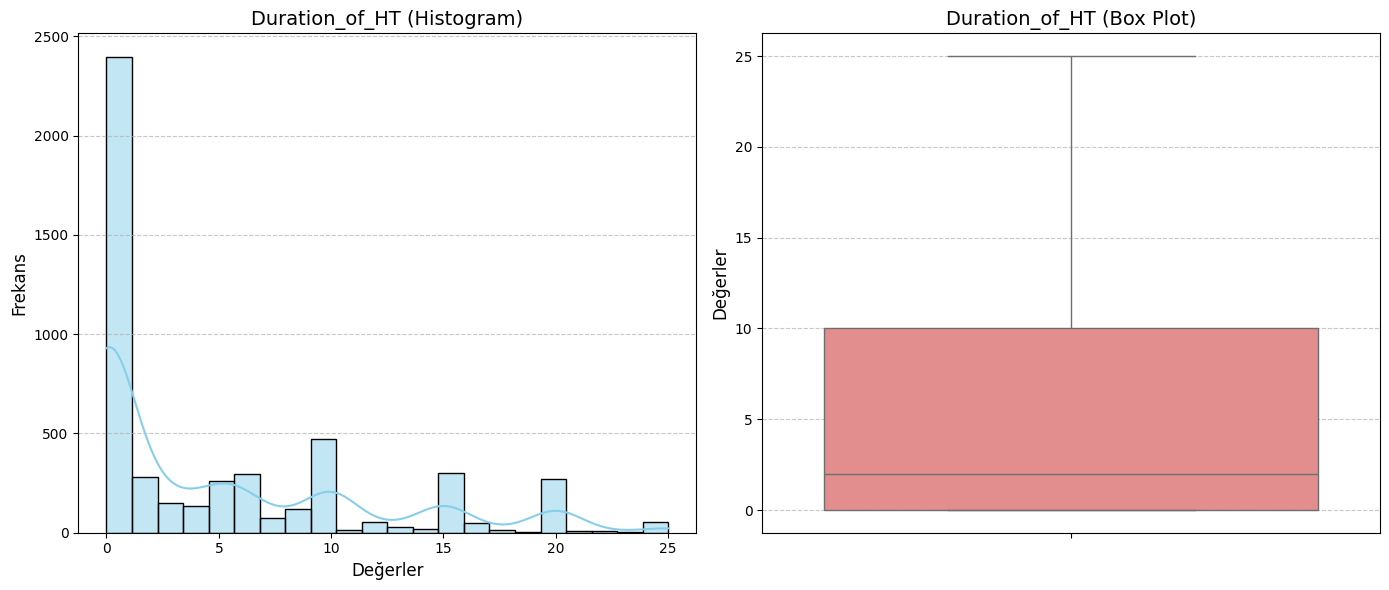

In [ ]:
histog_boxplot(df.Duration_of_HT)

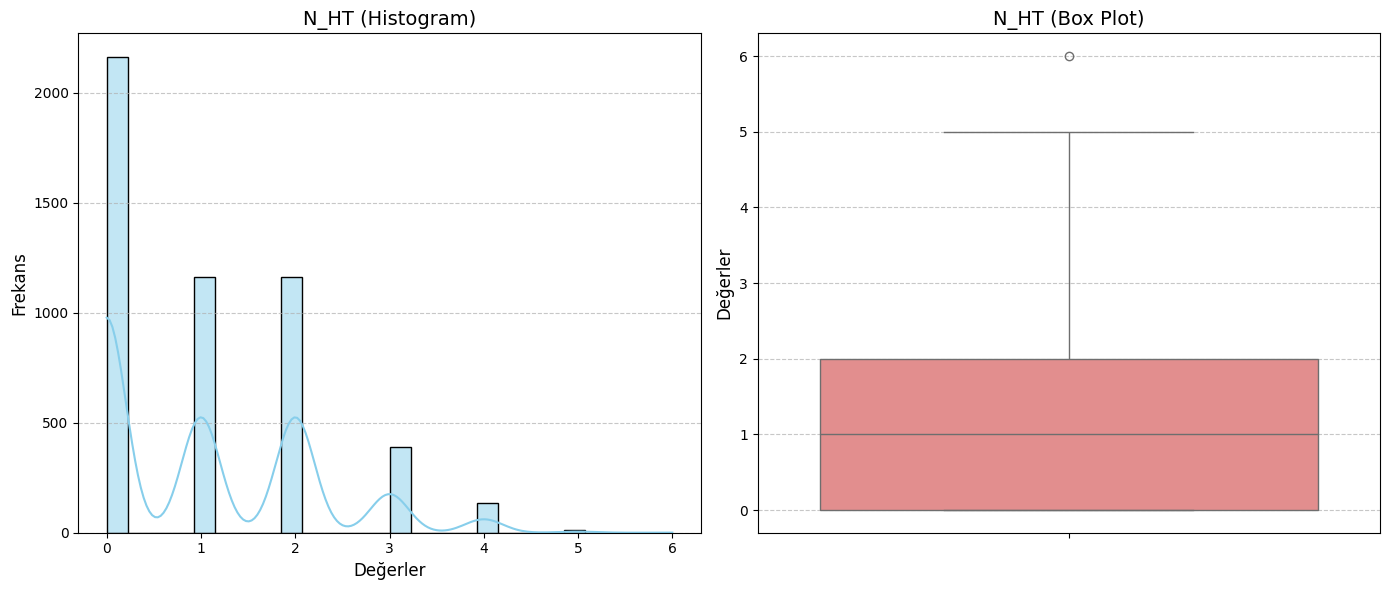

In [ ]:
histog_boxplot(df.N_HT)

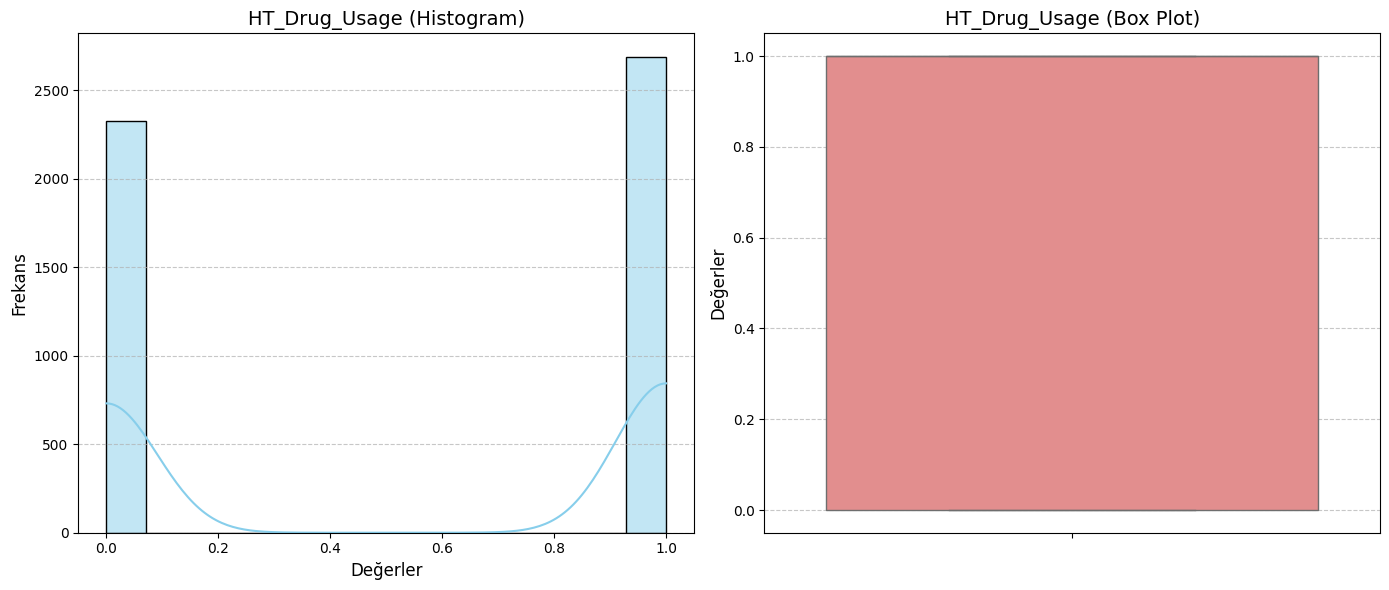

In [ ]:
histog_boxplot(df.HT_Drug_Usage)

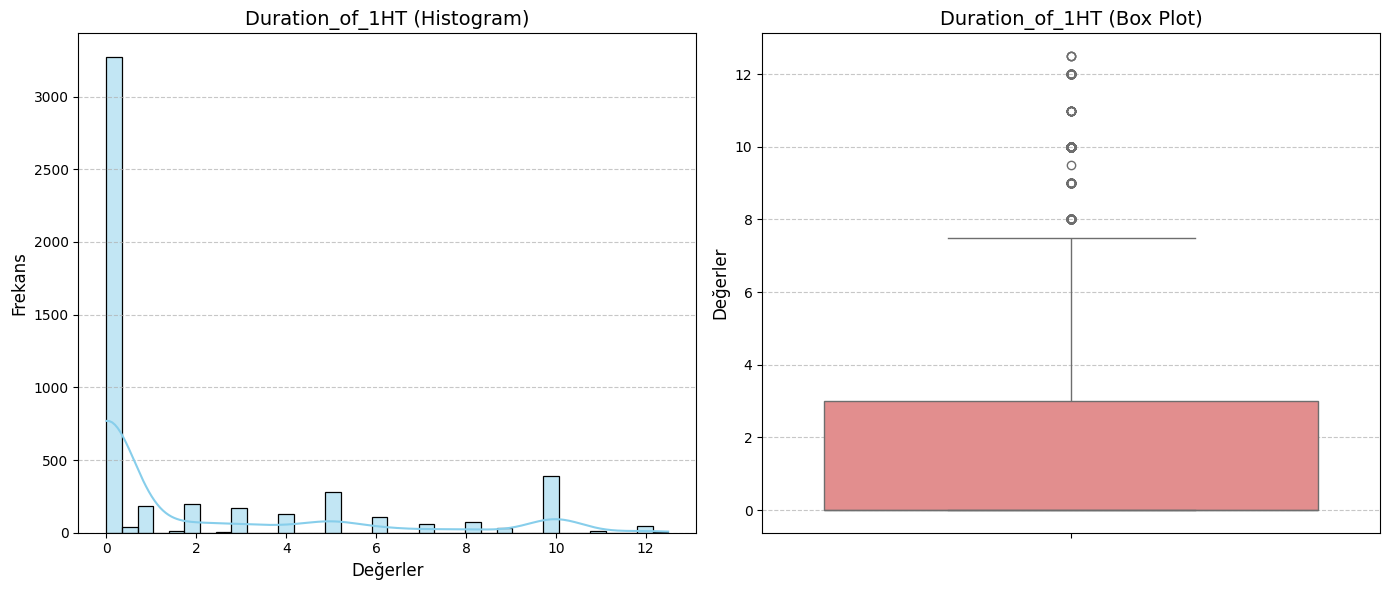

In [ ]:
histog_boxplot(df.Duration_of_1HT)

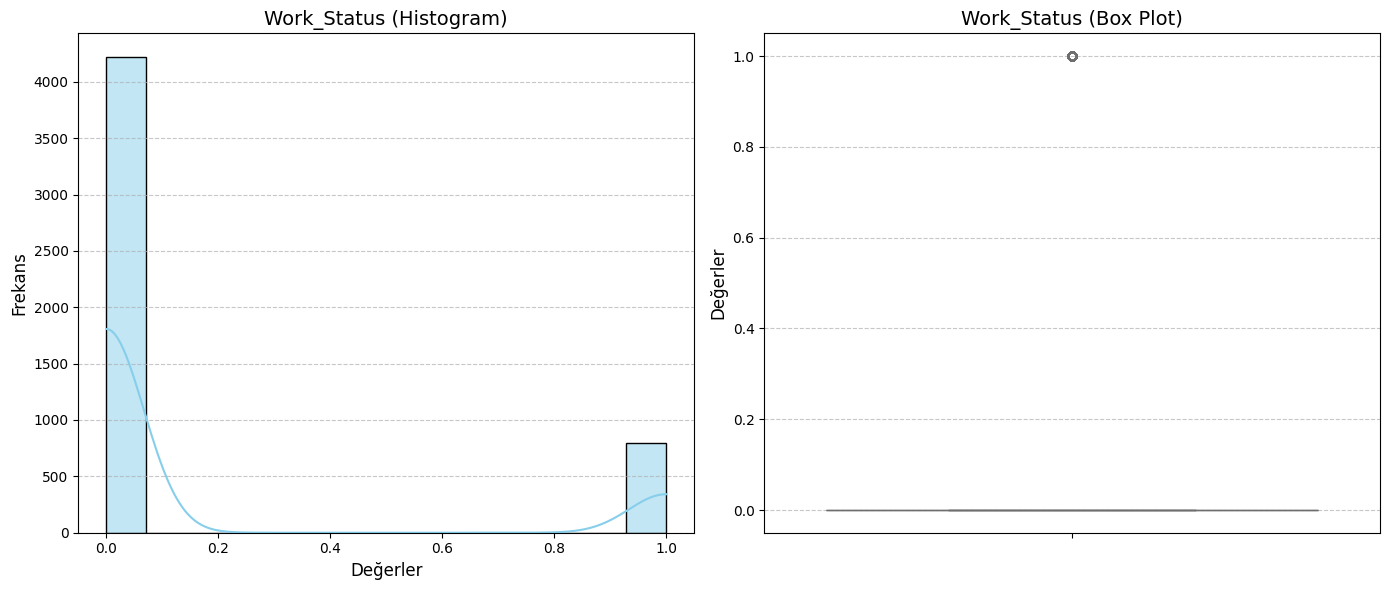

In [ ]:
histog_boxplot(df.Work_Status)

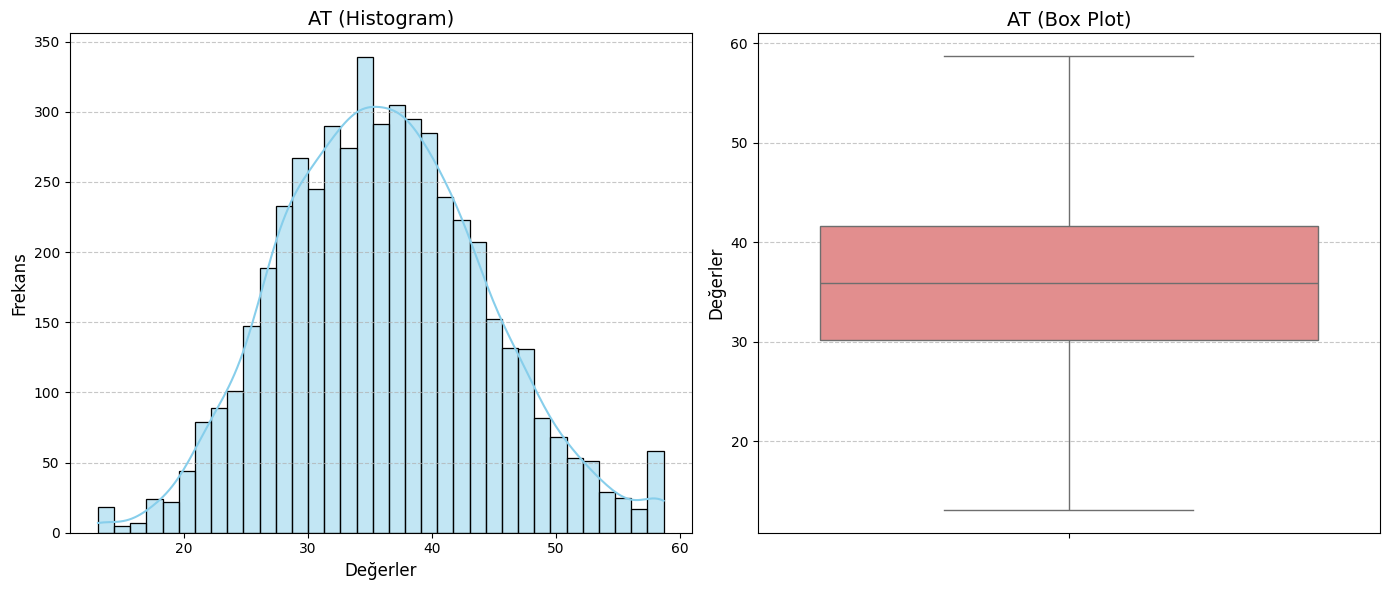

In [ ]:
histog_boxplot(df.AT)

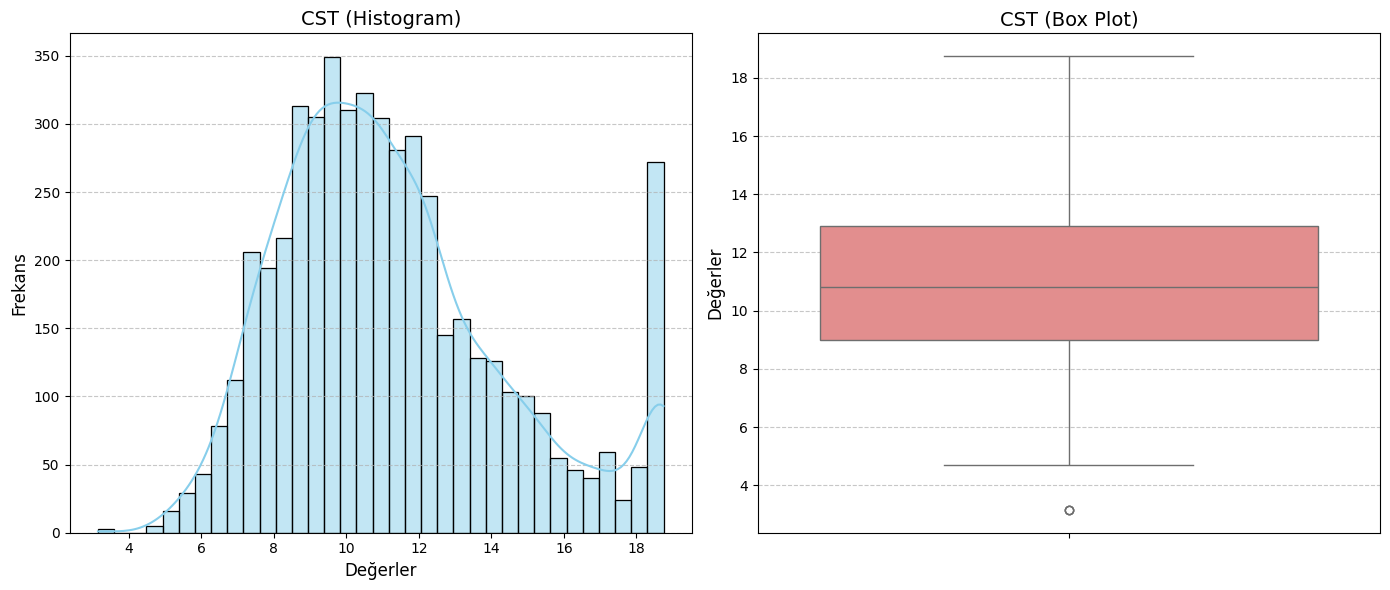

In [ ]:
histog_boxplot(df.CST)

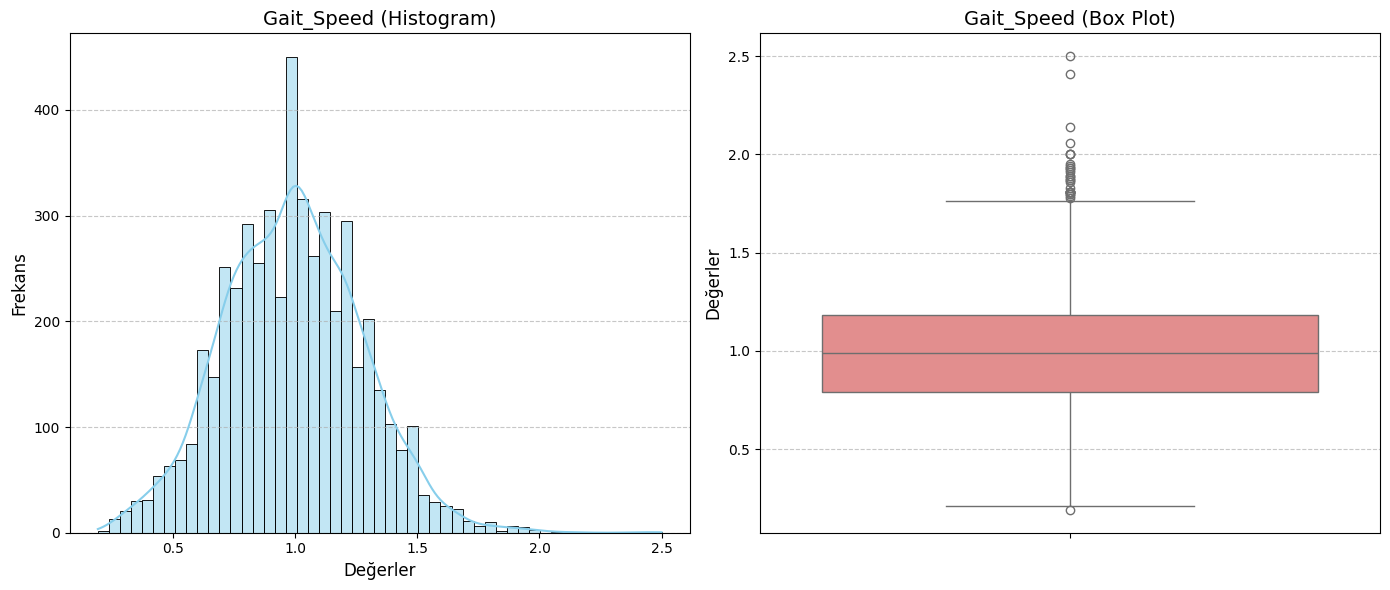

In [ ]:
histog_boxplot(df.Gait_Speed)

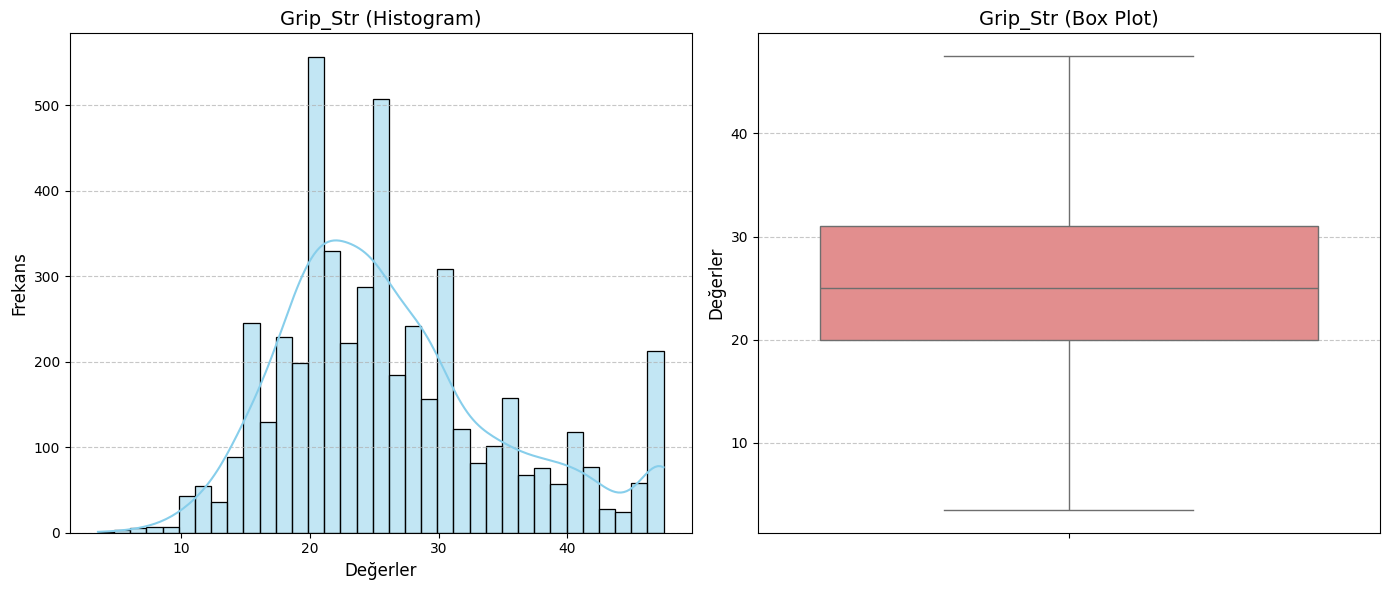

In [ ]:
histog_boxplot(df.Grip_Str)

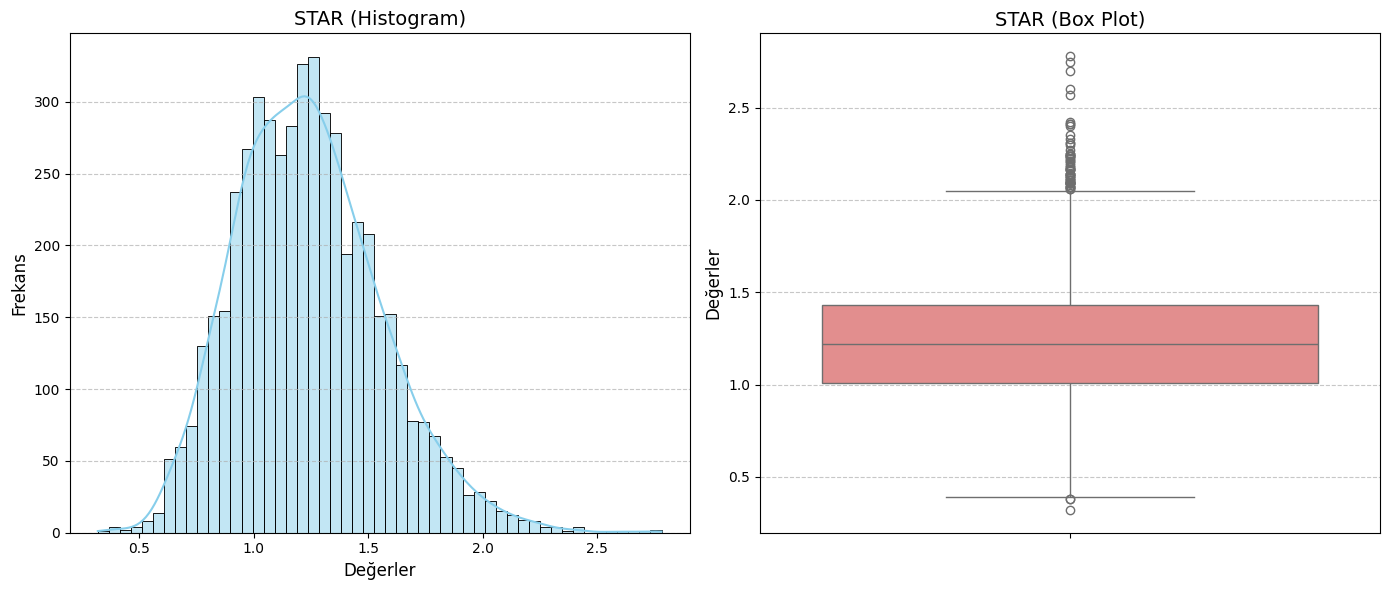

In [ ]:
histog_boxplot(df.STAR)

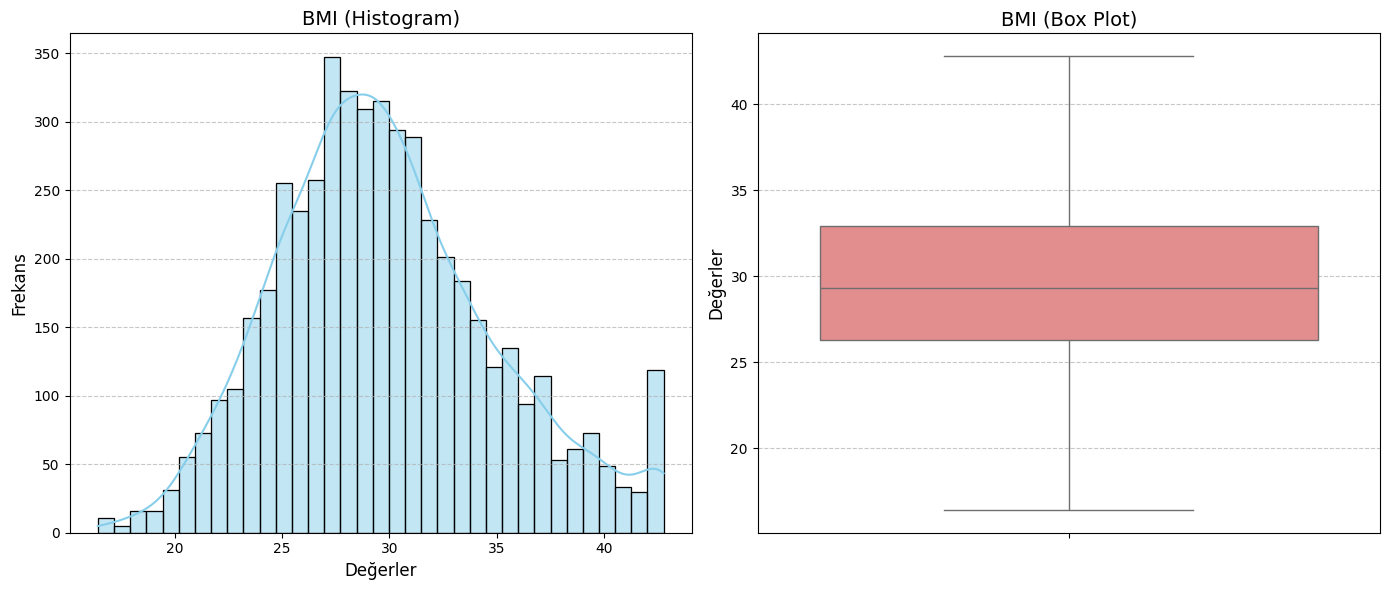

In [ ]:
histog_boxplot(df.BMI)

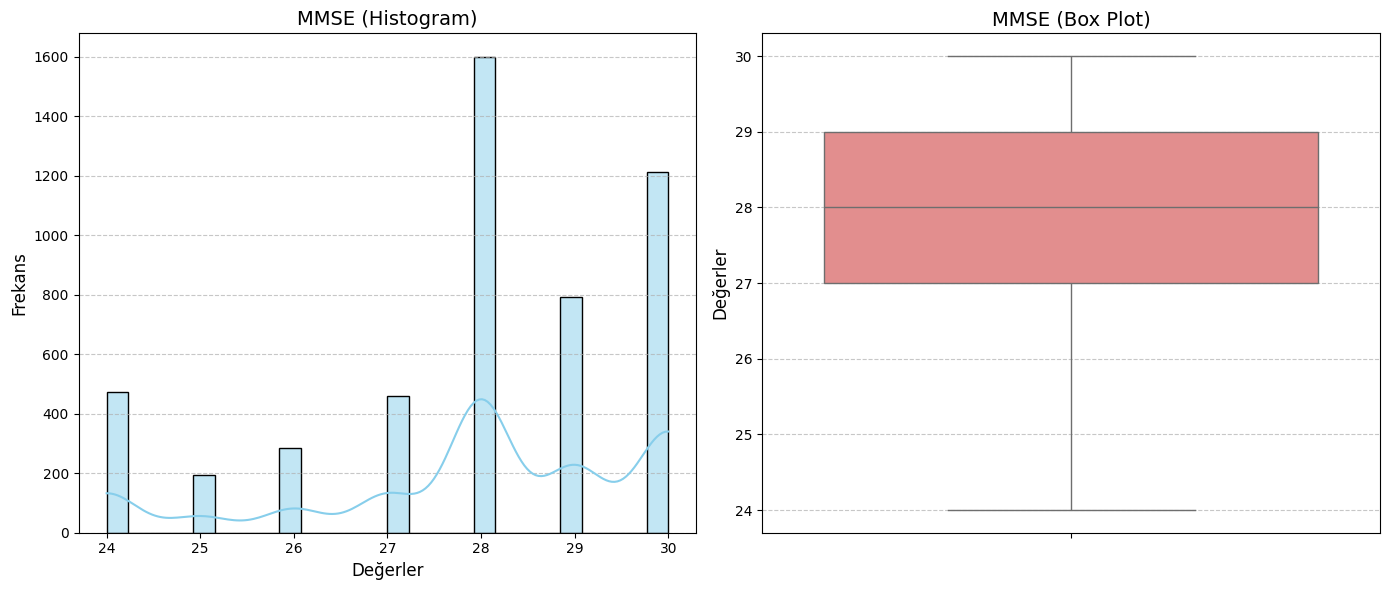

In [ ]:
histog_boxplot(df.MMSE)

In [ ]:
df.Sarcopenia.describe()

,Sarcopenia
count,5016.000000
mean,0.203150
std,0.402383
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


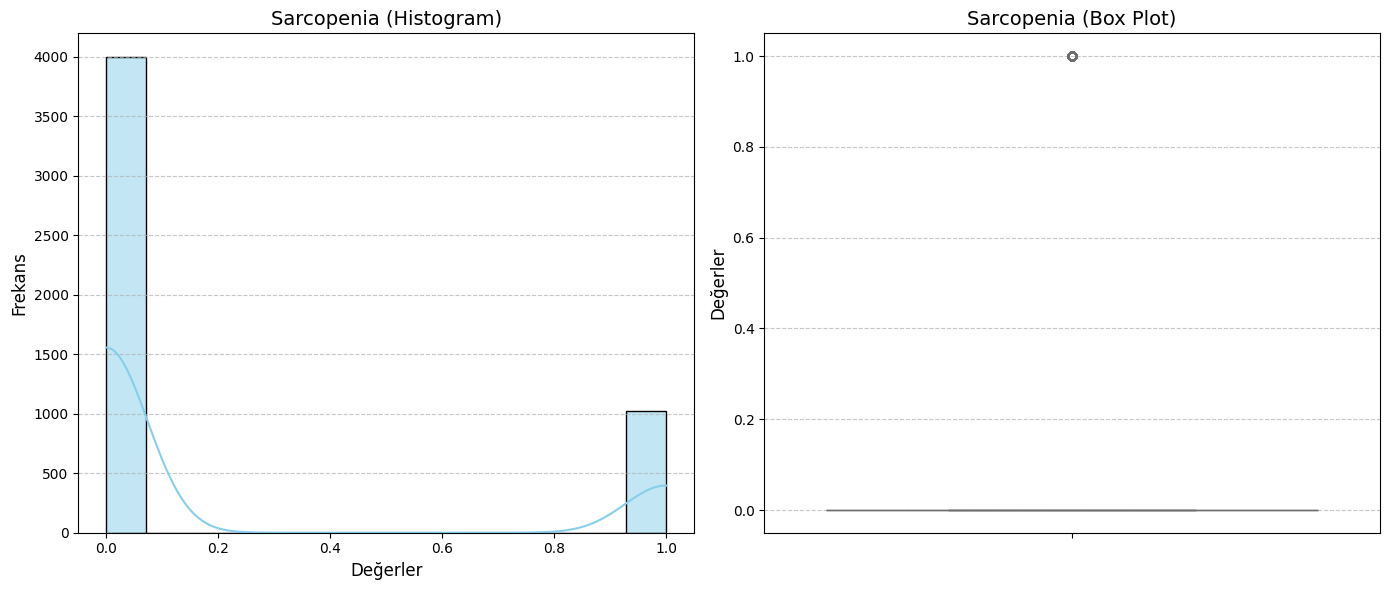

In [ ]:
histog_boxplot(df.Sarcopenia)

**y ekseninde ölçek azaltmak için grafikte "histog_boxplot_2" fonksiyonu kullanıldı.**

In [ ]:
def histog_boxplot_2(column):
    # Figür ve alt grafikleri oluşturalım
    # 1 satır, 2 sütunlu bir düzen oluştururuz
    # figsize, tüm figürün boyutunu (genişlik, yükseklik) piksel cinsinden ayarlar
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 satır, 2 sütun

    # --- Birinci Alt Grafik: Histogram ---
    # axes[0] ilk alt grafiği temsil eder (sol taraf)
    sns.histplot(column, kde=True, ax=axes[0], color='skyblue') # kde=True yoğunluk tahmini çizgisi ekler
    # Concatenate the column name and description into a single string for the title
    axes[0].set_title(f'{column.name} (Histogram)', fontsize=14)
    axes[0].set_xlabel('Değerler', fontsize=12)
    axes[0].set_ylabel('Frekans', fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)


    # --- İkinci Alt Grafik: Box Plot ---
    # axes[1] ikinci alt grafiği temsil eder (sağ taraf)
    sns.boxplot(y=column, ax=axes[1], color='lightcoral') # Sadece tek bir sütun olduğu için 'y' eksenine atarız
    # Concatenate the column name and description into a single string for the title
    axes[1].set_title(f'{column.name} (Box Plot)', fontsize=14)
    axes[1].set_ylabel('Değerler', fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)


    # Grafiklerin düzenini optimize edelim ve çakışmaları önleyelim
    plt.tight_layout()

    # Return the figure and axes objects
    return fig, axes

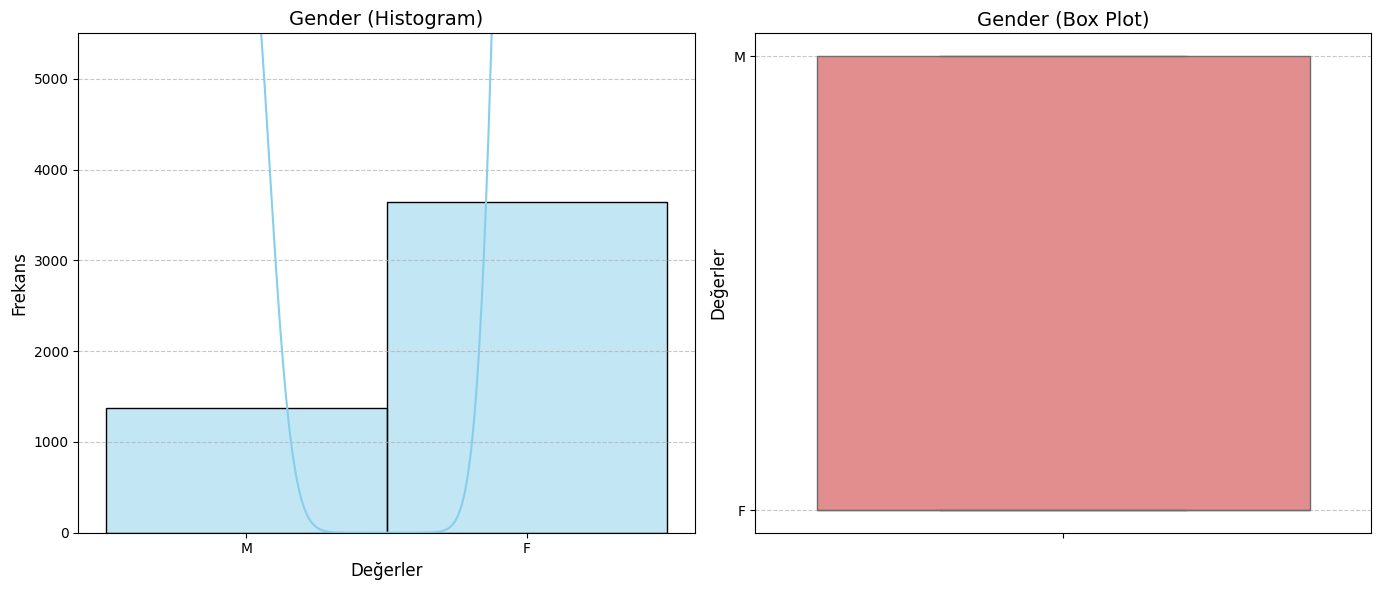

In [ ]:
fig, axes = histog_boxplot_2(df.Gender)
axes[0].set_ylim(0, 5500)
  # Grafiği gösterelim
plt.show()

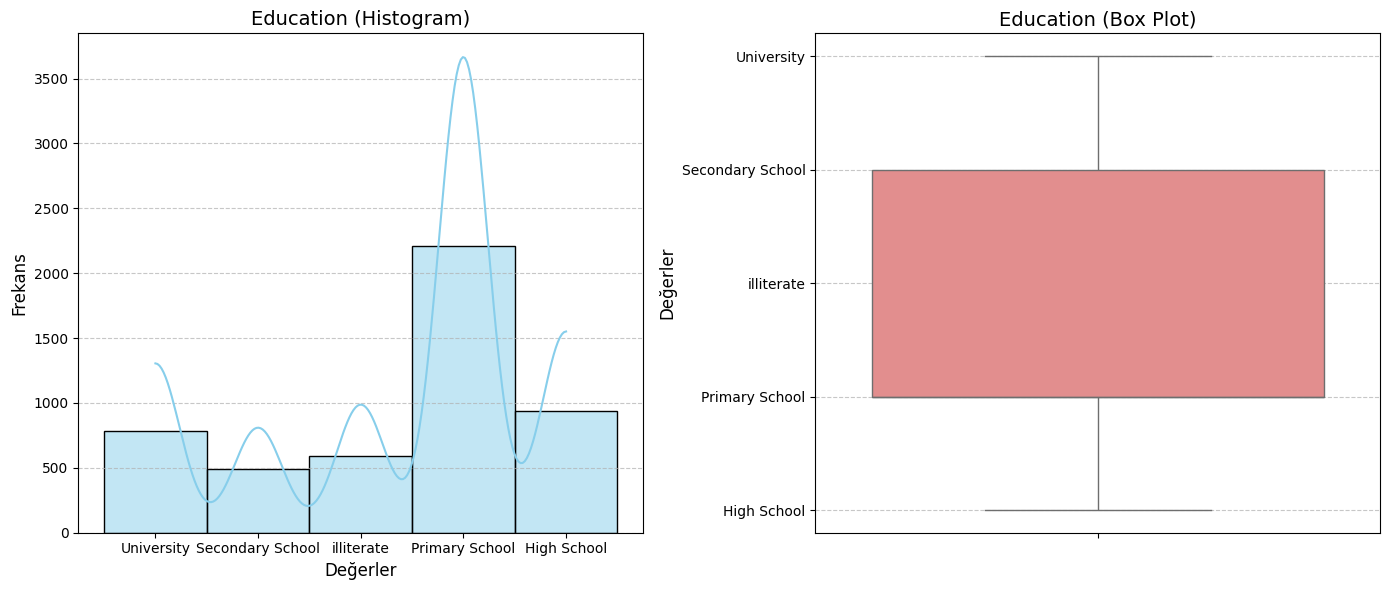

In [ ]:
histog_boxplot(df.Education)

**Kategorik değerleri y ekseninde göstermek amacıyla "histog_boxplot_3" fonksiyonu kullanıldı.**

In [ ]:
def histog_boxplot_3(column):
  # Figür ve alt grafikleri oluşturalım
    # 1 satır, 2 sütunlu bir düzen oluştururuz
    # figsize, tüm figürün boyutunu (genişlik, yükseklik) piksel cinsinden ayarlar
    fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Yatay grafikler için biraz daha geniş bir figür

    # --- Birinci Alt Grafik: Yatay Histogram ---
    # axes[0] ilk alt grafiği temsil eder (sol taraf)
    # x yerine 'y' parametresini kullanarak histogramı yatay çizeriz.
    sns.histplot(y=column, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{column.name} (Histogram - Yatay)', fontsize=14)
    axes[0].set_xlabel('Frekans', fontsize=12) # Frekans şimdi X ekseninde
    axes[0].set_ylabel(column.name, fontsize=12) # Sütun adı şimdi Y ekseninde
    axes[0].grid(axis='x', linestyle='--', alpha=0.7) # Yatay histogramda X eksenine ızgara

    # --- İkinci Alt Grafik: Box Plot ---
    # axes[1] ikinci alt grafiği temsil eder (sağ taraf)
    sns.boxplot(x=column, ax=axes[1], color='lightcoral', orient='h') # orient='h' yatay çizim için
    axes[1].set_title(f'{column.name} (Box Plot - Yatay)', fontsize=14)
    axes[1].set_xlabel(column.name, fontsize=12) # Sütun adı şimdi X ekseninde
    axes[1].set_ylabel('Değerler (Y ekseni boş)', fontsize=12) # Y ekseni boş kalacak veya sabit bir değer gösterecek
    axes[1].grid(axis='x', linestyle='--', alpha=0.7) # Yatay box plot'ta X eksenine ızgara


    # Grafiklerin düzenini optimize edelim ve çakışmaları önleyelim
    plt.tight_layout()

    # Grafiği gösterelim
    plt.show()

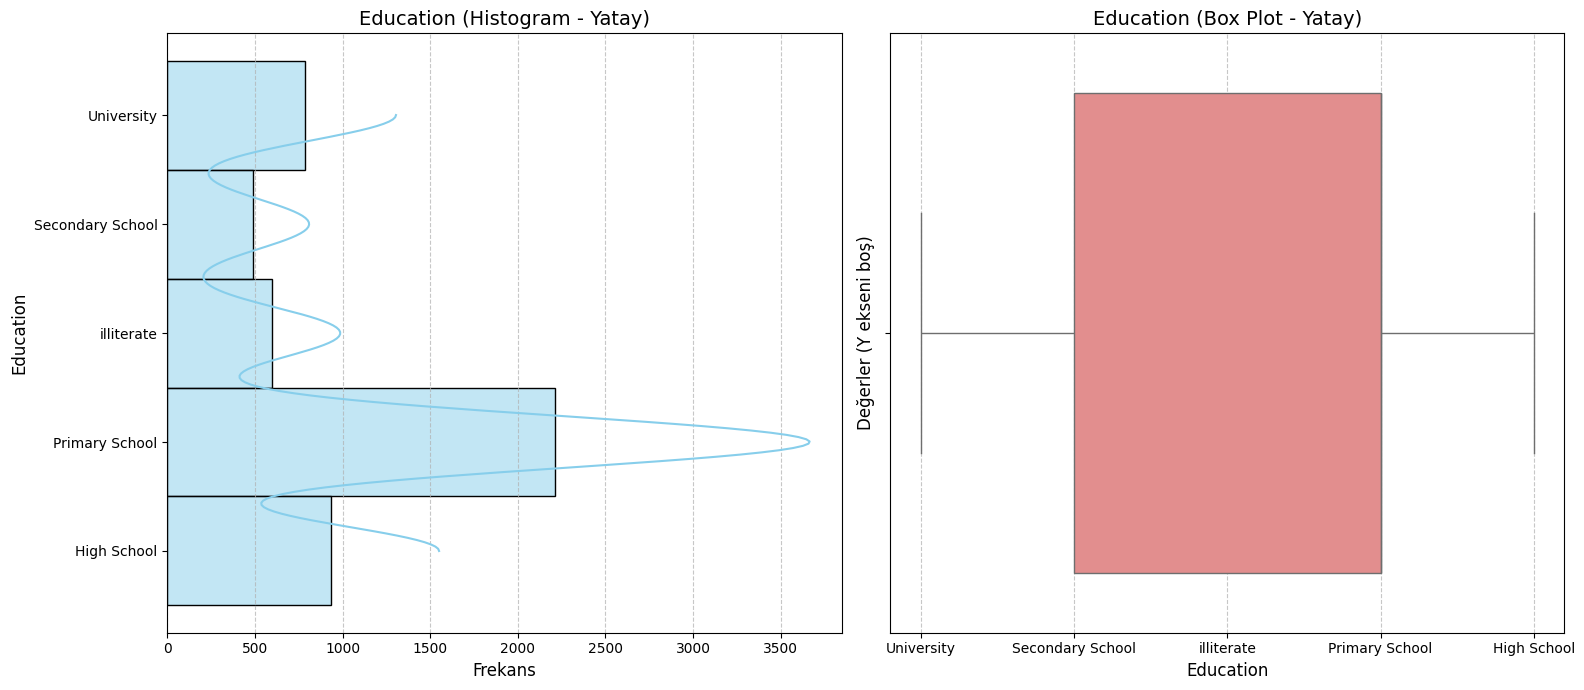

In [ ]:
histog_boxplot_3(df.Education)

In [ ]:
df["Exercise_Status"] = (df.Exercise != 0).astype(int).astype(str)

In [ ]:
df.Exercise_Status.value_counts()

,count
Exercise_Status,
0,2928
1,2088


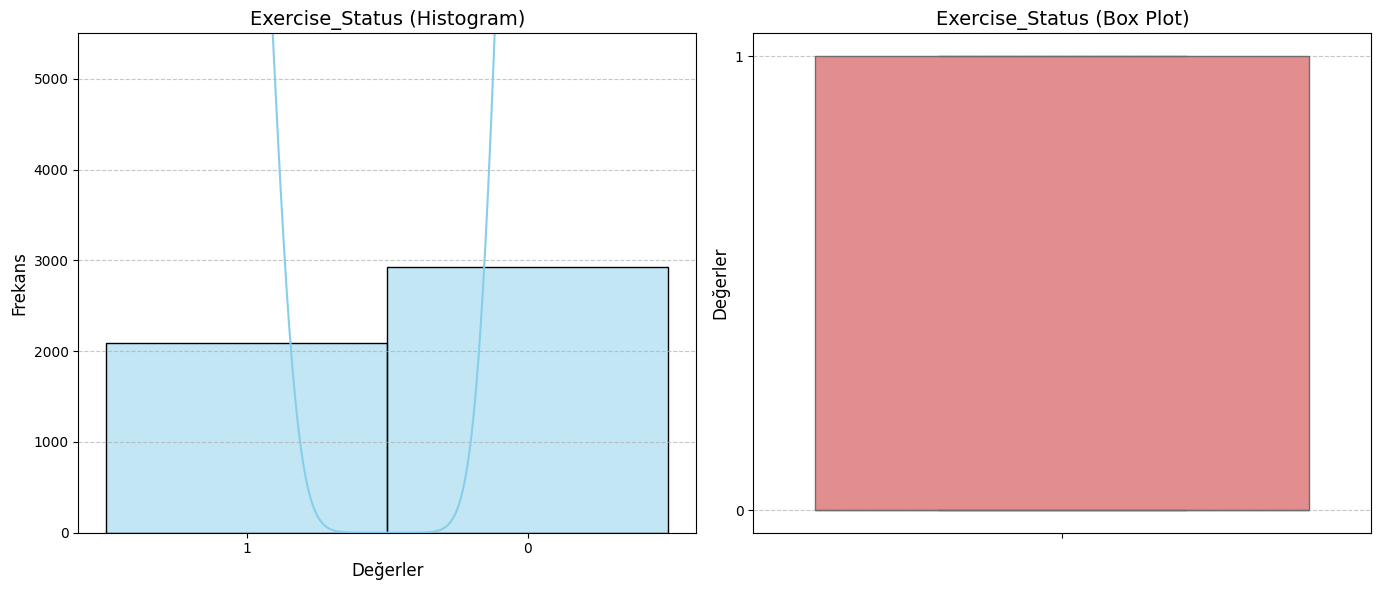

In [ ]:
fig, axes = histog_boxplot_2(df.Exercise_Status)
axes[0].set_ylim(0, 5500)
  # Grafiği gösterelim
plt.show()

In [ ]:
new_column_4 = df.pop("Exercise_Status")

In [ ]:
df.insert(35, "Exercise_Status", new_column_4)

In [ ]:
df.columns

Index(['Name', 'Order', 'Gender', 'Age', 'Weight', 'Height', 'Waist', 'Hip',
       'Smoking', 'Smoking_packet_per_year', 'Alcohol', 'DM_Type2',
       'DM_Type2_Duration', 'Insulin', 'DM_Type2_Drug', 'DM_Type2_Drug_Usage',
       'Dyslipidemia', 'Dyslipidemia_duration', 'KAH', 'KAH_Duration',
       'Hipotiroidi', 'Asthma', 'COPD', 'OP', 'HT', 'Duration_of_HT', 'N_HT',
       'HT_drugs', 'HT_Drug_Usage', 'Duration_of_1HT', 'Education', 'Job',
       'Status', 'Work_Status', 'Exercise', 'Exercise_Status', 'AT', 'CST',
       'Gait_Speed', 'Grip_Str', 'STAR', 'BMI', 'MMSE', 'Sarcopenia'],
      dtype='object')

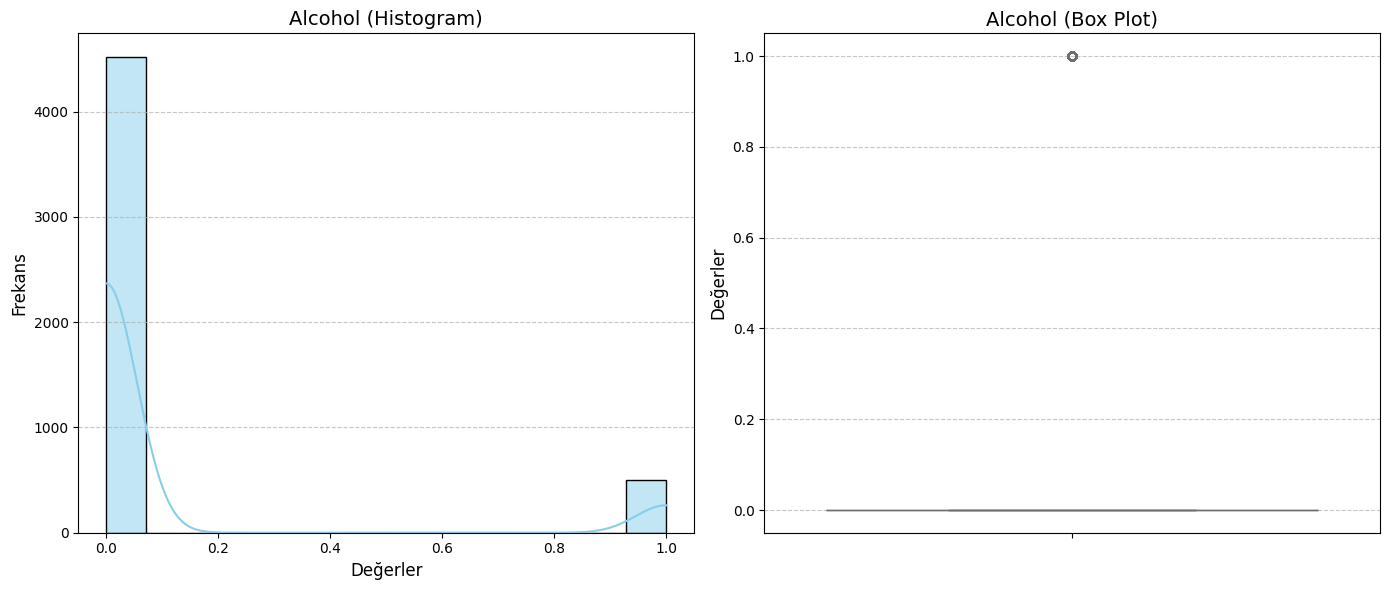

In [ ]:
histog_boxplot(df.Alcohol)

# **Bi-variate Analysis**

**Correlation Matrix of Numerical Values**

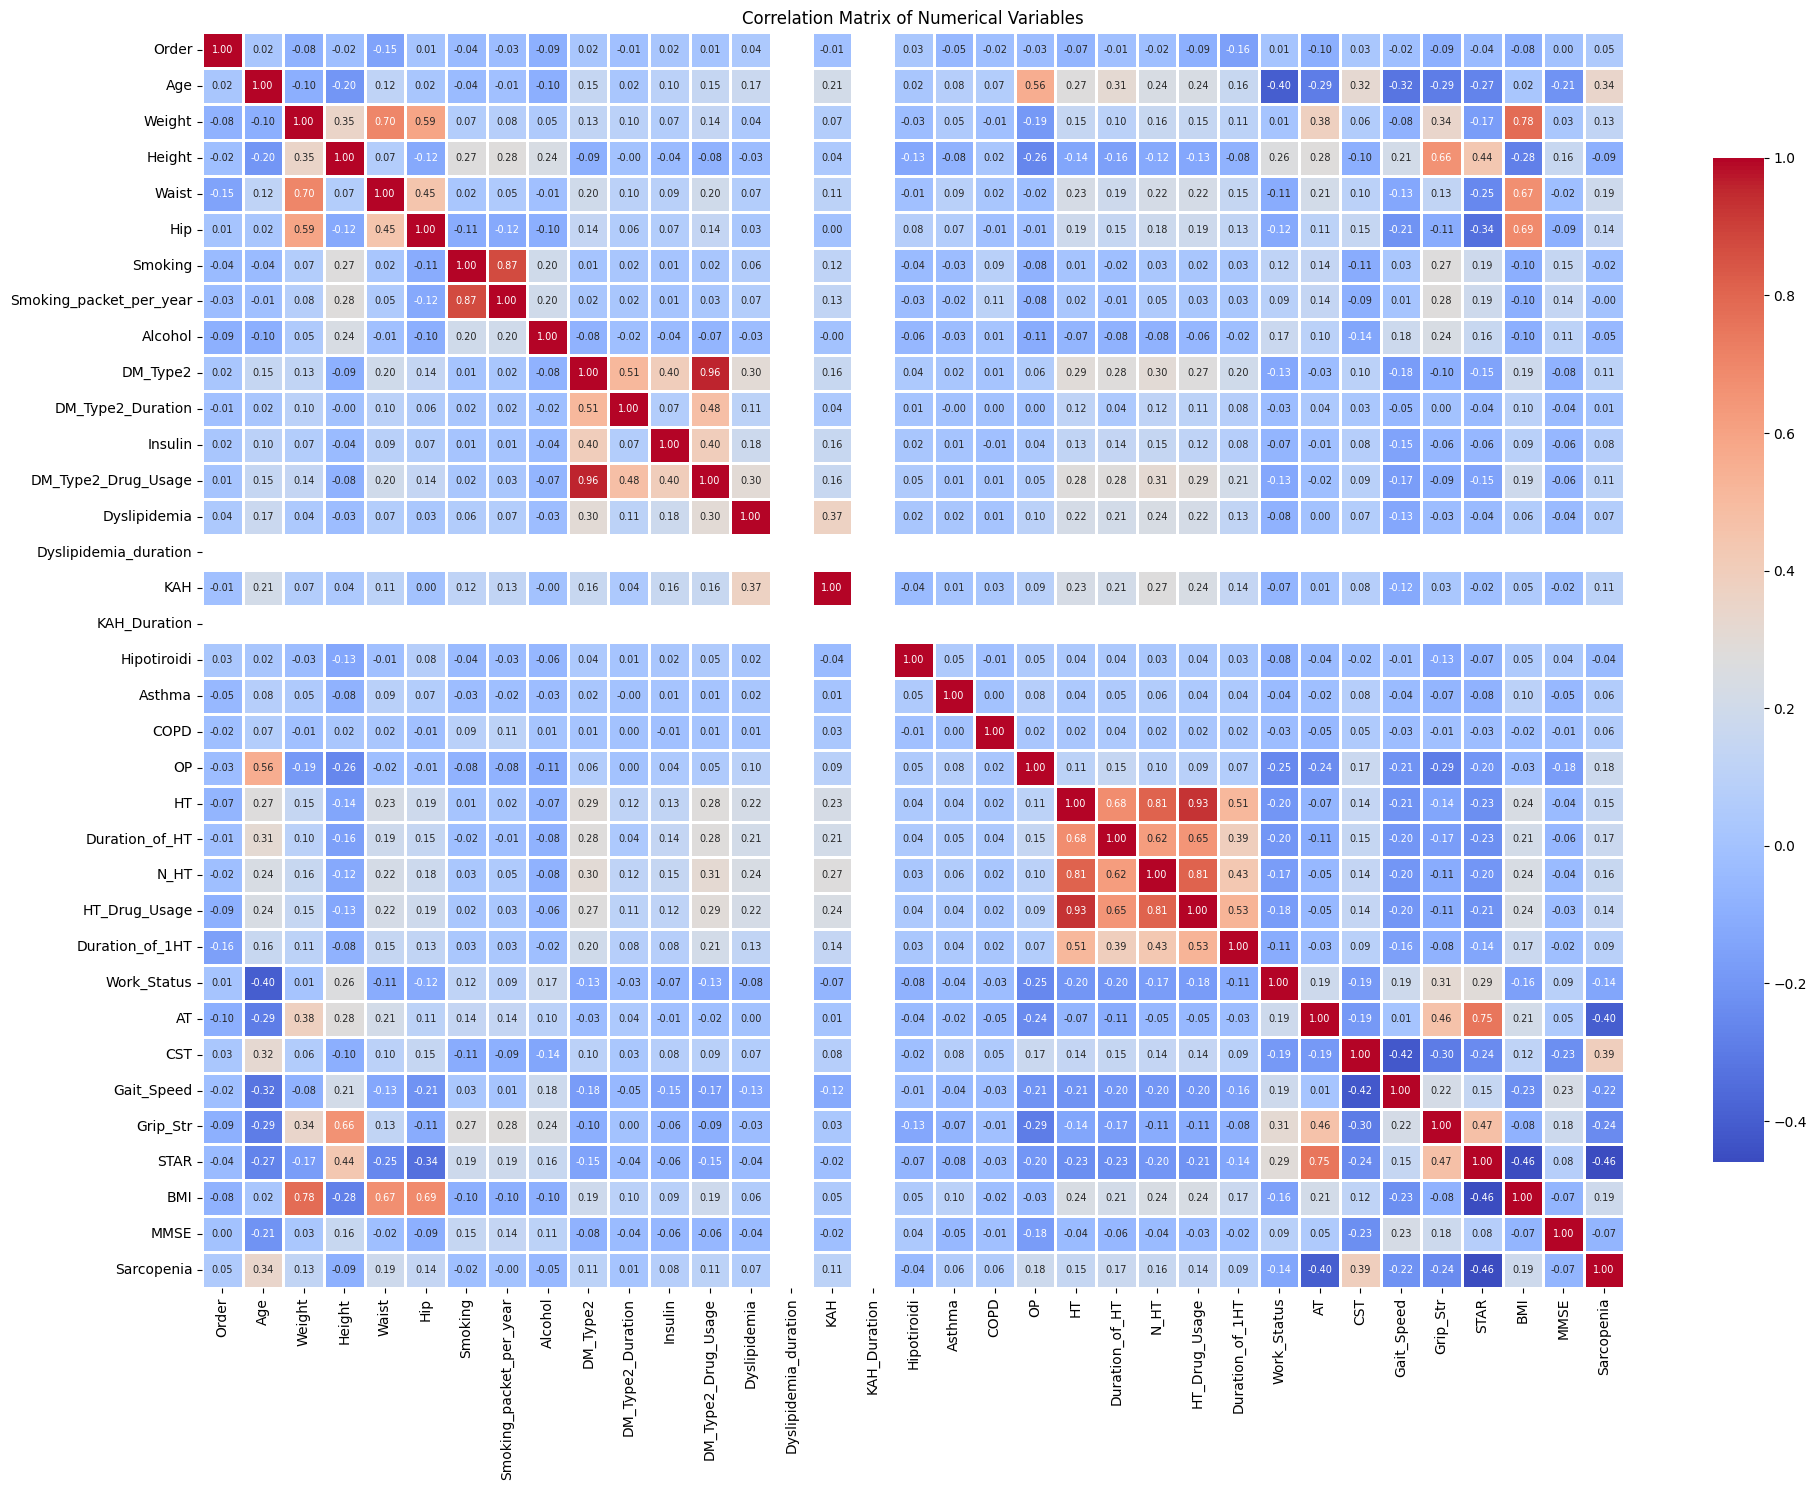

In [ ]:
df_numeric = df.select_dtypes(include=np.number)
correlation_matrix = df_numeric.corr().round(2)

num_cols = len(df_numeric.columns)

fig_width = num_cols * 0.7 # Her sütun/satır için yaklaşık 0.7 inç ayırıyoruz
fig_height = num_cols * 0.7

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 15)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=1,cbar_kws={'shrink': 0.8},
    annot_kws={"fontsize": 7})
plt.title('Correlation Matrix of Numerical Variables')

plt.xticks(rotation=90, fontsize=10)  # X ekseni etiketlerini dikey yap ve font boyutunu ayarla
plt.yticks(rotation=0, fontsize=10) # Y ekseni etiketlerini yatay bırak ve font boyutunu ayarla

# Grafiklerin düzenini optimize edelim ve çakışmaları önleyelim
plt.tight_layout()
plt.show()

In [ ]:
df.KAH_Duration.describe()

,KAH_Duration
count,5016.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


<Axes: xlabel='KAH_Duration', ylabel='Sarcopenia'>

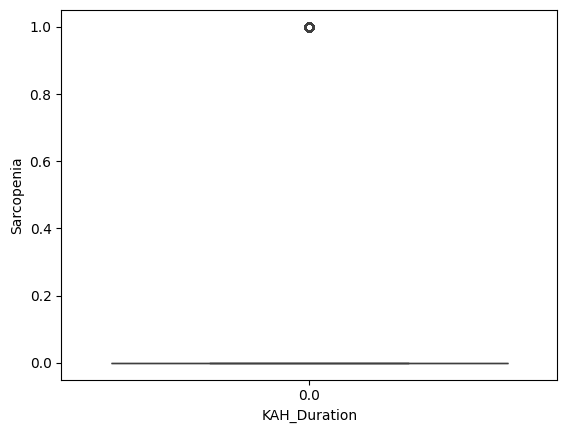

In [ ]:
sns.boxplot(x='KAH_Duration', y='Sarcopenia', data=df)

In [ ]:
df['KAH_Duration'].corr(df['Sarcopenia'])

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(nan)

**Varyansı ve standart sapması 0 olan değerler arasında ilişki kurulamıyor.**

<Axes: xlabel='Dyslipidemia_duration', ylabel='Sarcopenia'>

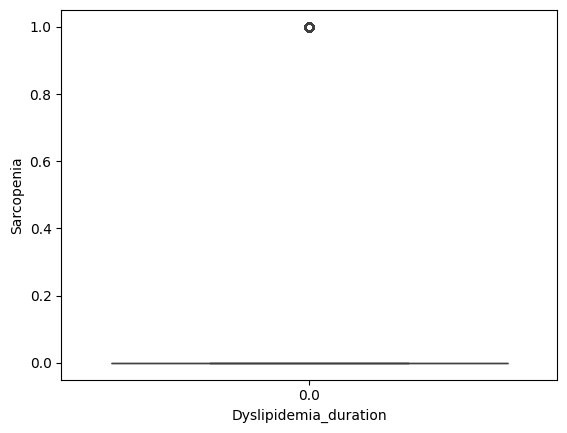

In [ ]:
sns.boxplot(x='Dyslipidemia_duration', y='Sarcopenia', data=df)

# **Numerical vs. Numerical**

In [ ]:
def bivariate_scatter (column1,column2):
  # Use the .name attribute to get the column names as strings
  sns.scatterplot(x=column1.name, y=column2.name, data=df, hue='Sarcopenia', palette=['skyblue', 'orange'])
  plt.title(f'{column1.name} vs {column2.name} Distribution', fontsize=16)
  plt.xlabel(f'{column1.name} Durumu', fontsize=12)
  plt.ylabel(f'{column2.name}', fontsize=12)

  # Izgara ekleyelim
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  # Grafiği göster
  plt.tight_layout()
  plt.show()

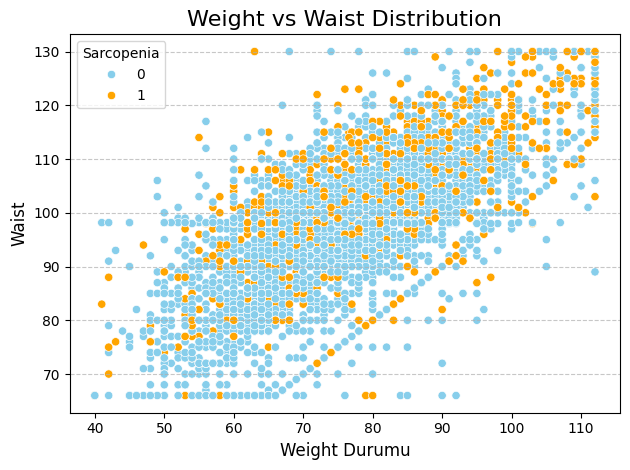

In [ ]:
bivariate_scatter (df.Weight,df.Waist)

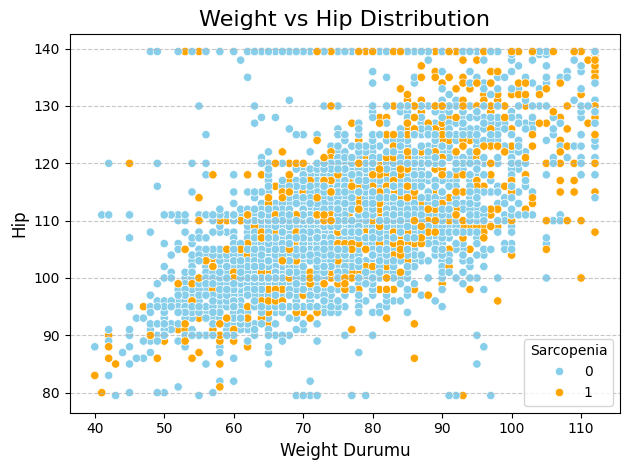

In [ ]:
bivariate_scatter (df.Weight,df.Hip)

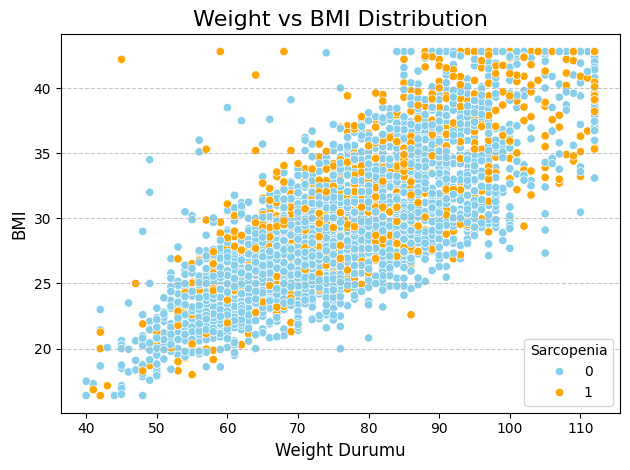

In [ ]:
bivariate_scatter (df.Weight,df.BMI)

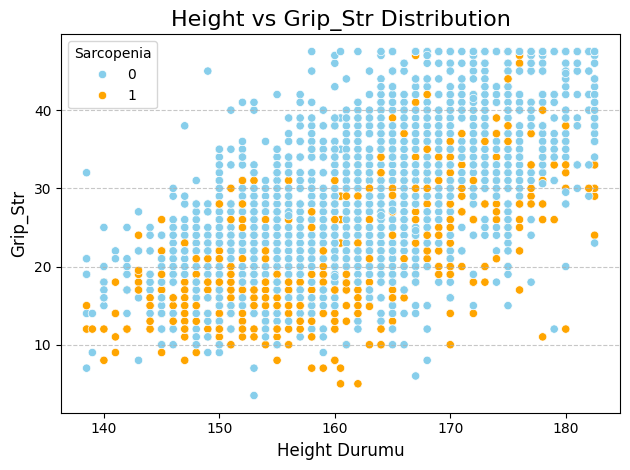

In [ ]:
bivariate_scatter (df.Height,df.Grip_Str)

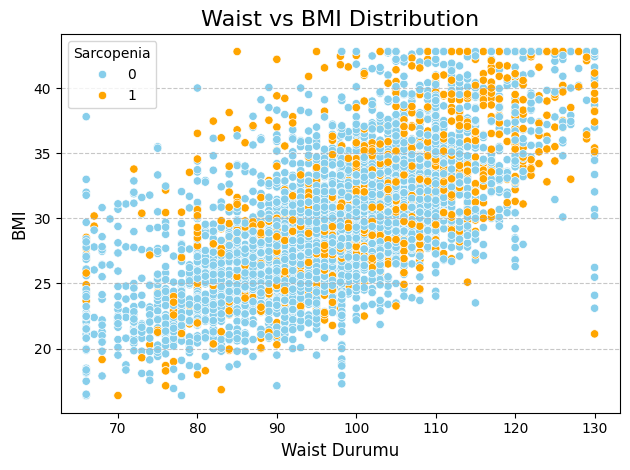

In [ ]:
bivariate_scatter (df.Waist,df.BMI)

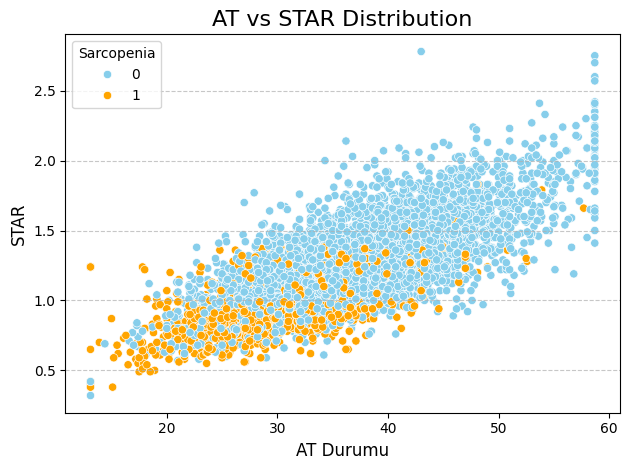

In [ ]:
bivariate_scatter (df.AT,df.STAR)

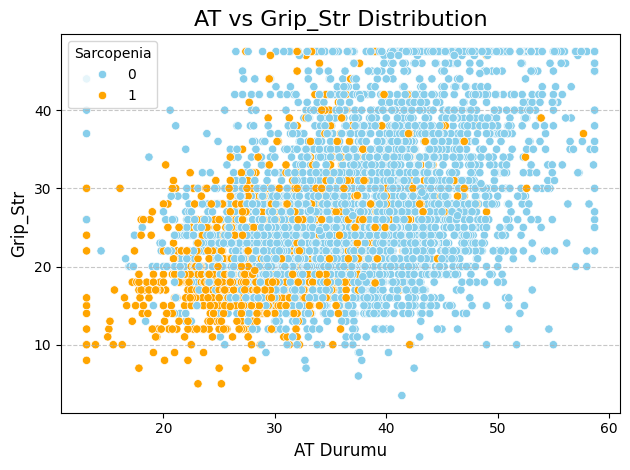

In [ ]:
bivariate_scatter (df.AT,df.Grip_Str)

# **Numerical vs. Sarcopenia**

In [ ]:
def bivariate (column1,column2):
  # Use the .name attribute to get the column names as strings
  sns.boxplot(x=column1.name, y=column2.name, data=df, hue='Sarcopenia', palette=['skyblue', 'orange'])
  plt.title(f'{column1.name} vs {column2.name} Distribution', fontsize=16)
  plt.xlabel(f'{column1.name} Durumu', fontsize=12)
  plt.ylabel(f'{column2.name}', fontsize=12)

  # Izgara ekleyelim
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  # Grafiği göster
  plt.tight_layout()
  plt.show()

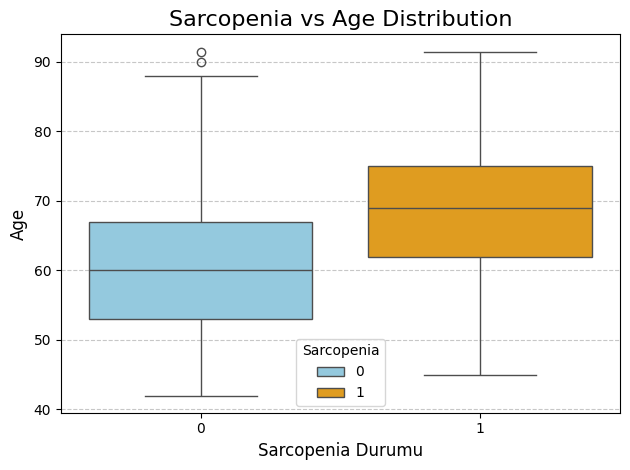

In [ ]:
bivariate (df.Sarcopenia,df.Age)

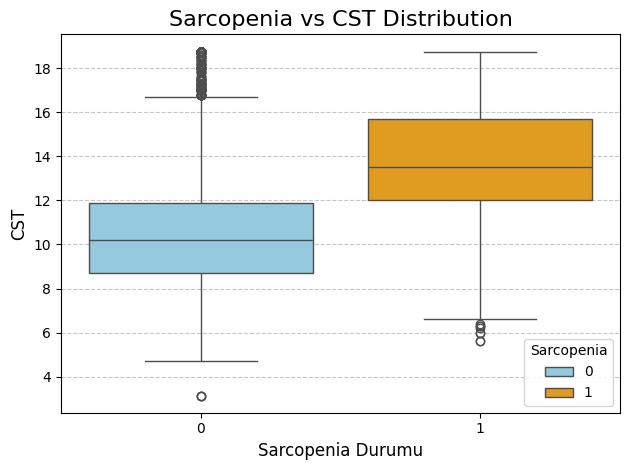

In [ ]:
bivariate (df.Sarcopenia,df.CST)

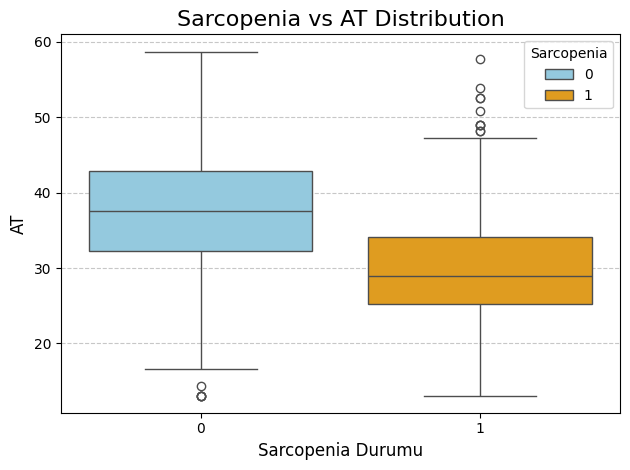

In [ ]:
bivariate (df.Sarcopenia,df.AT)

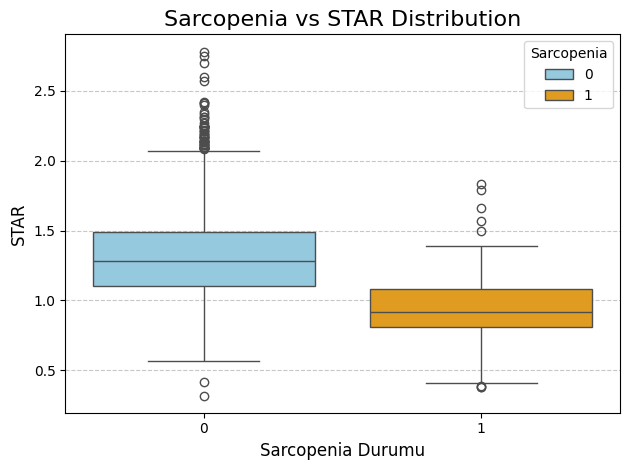

In [ ]:
bivariate (df.Sarcopenia,df.STAR)

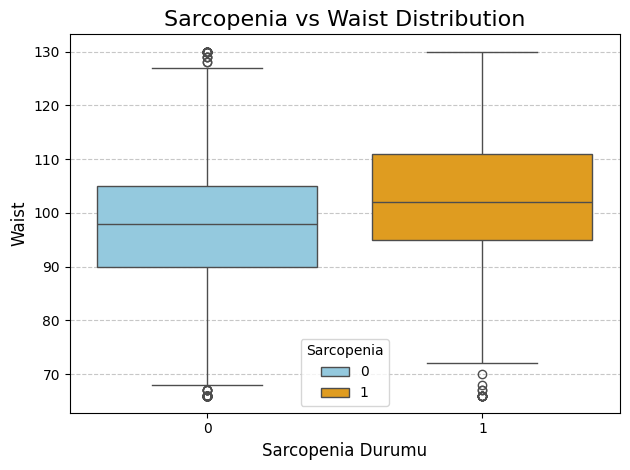

In [ ]:
bivariate (df.Sarcopenia,df.Waist)

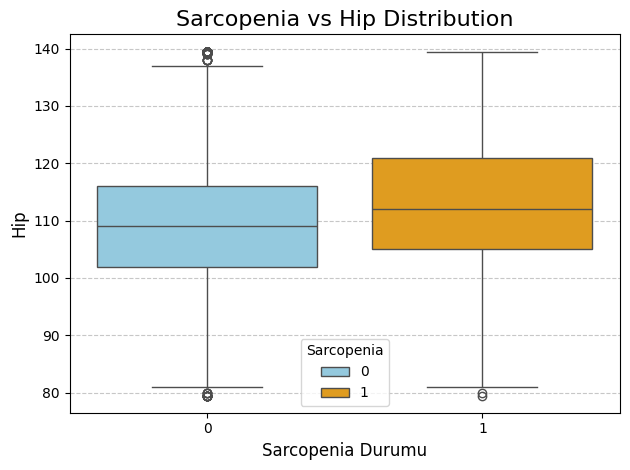

In [ ]:
bivariate (df.Sarcopenia,df.Hip)

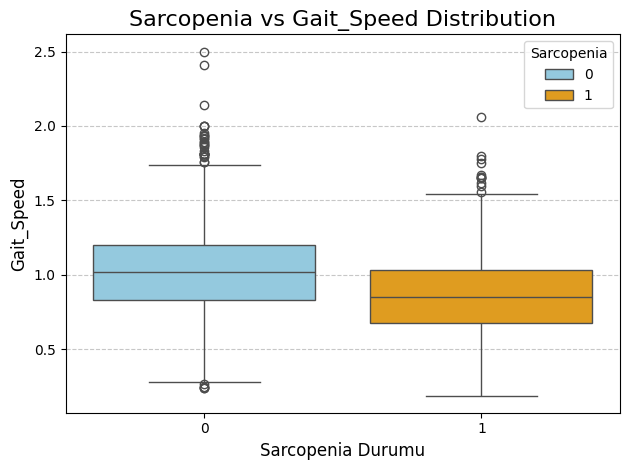

In [ ]:
bivariate (df.Sarcopenia,df.Gait_Speed)

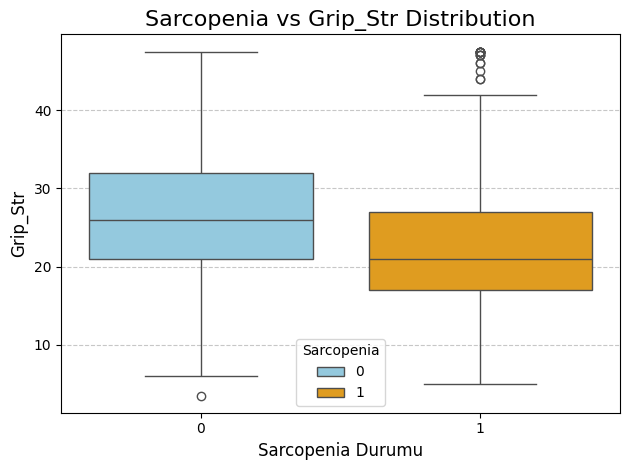

In [ ]:
bivariate (df.Sarcopenia,df.Grip_Str)

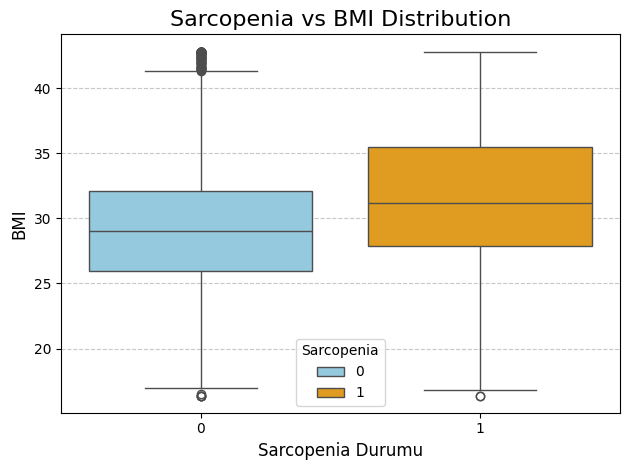

In [ ]:
bivariate (df.Sarcopenia,df.BMI)

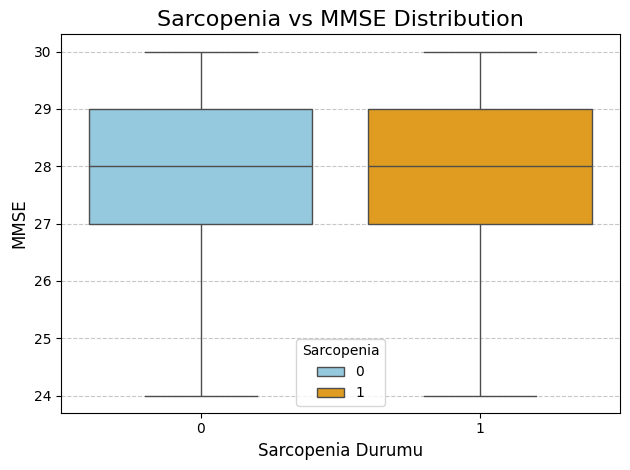

In [ ]:
bivariate (df.Sarcopenia,df.MMSE)

# **Categorical vs. Sarcopenia**

<Axes: xlabel='Sarcopenia'>

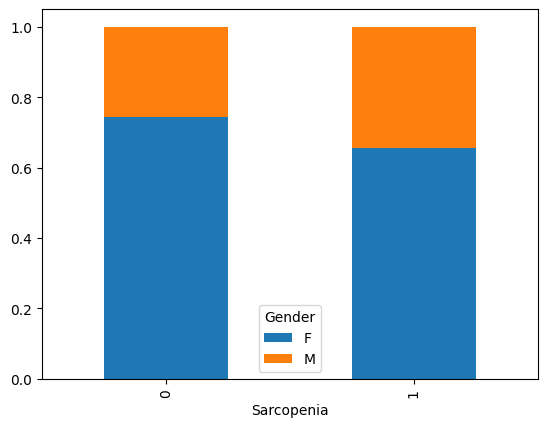

In [ ]:
pd.crosstab(df['Sarcopenia'], df['Gender'], normalize='index').plot(kind='bar', stacked=True)

In [ ]:
def bivariate_crosstab (column1, column2):
  # Categorical vs. Sarcopenia
  # Calculate the cross-tabulation and normalize by index (rows)
  crosstab_result = pd.crosstab(column1, column2, normalize='index')
  # Plot the result as a stacked bar chart
  crosstab_result.plot(kind='bar', stacked=True)

  # Add titles and labels for clarity
  plt.title(f'{column1.name} vs {column2.name} Distribution (Normalized by Sarcopenia Status)', fontsize=16)
  plt.xlabel(f'{column1.name} Status', fontsize=12)
  # Removed the redundant ylabel as normalize='index' implies proportion within the index categories
  plt.ylabel('Proportion within Sarcopenia Status', fontsize=12)
  plt.xticks(rotation=0) # Keep x-axis labels horizontal

  # Display the plot
  plt.show()


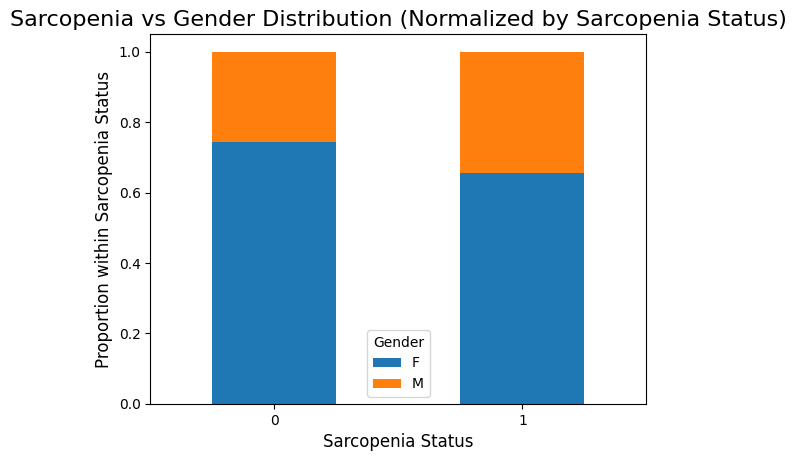

In [ ]:
bivariate_crosstab (df.Sarcopenia,df.Gender)

In [ ]:
def group_bar_chart(column1, column2):
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x='Gender', hue='Sarcopenia', palette="pastel") # You can change the palette

  #Customize the plot (optional but recommended)
  plt.title('Sarcopenia by Gender', fontsize=14)
  plt.xlabel('Gender', fontsize=12)
  plt.ylabel('count', fontsize=12)
  plt.legend(title='Sarcopenia', labels=['0', '1']) # Assuming 0 and 1 represent absence/presence

  #Show the plot
  plt.tight_layout()
  plt.show()

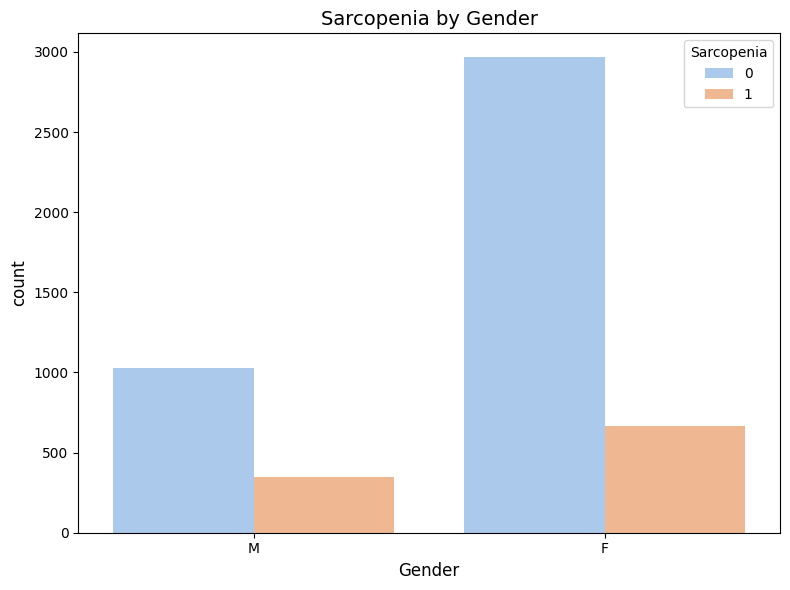

In [ ]:
group_bar_chart(df.Gender,df.Sarcopenia)

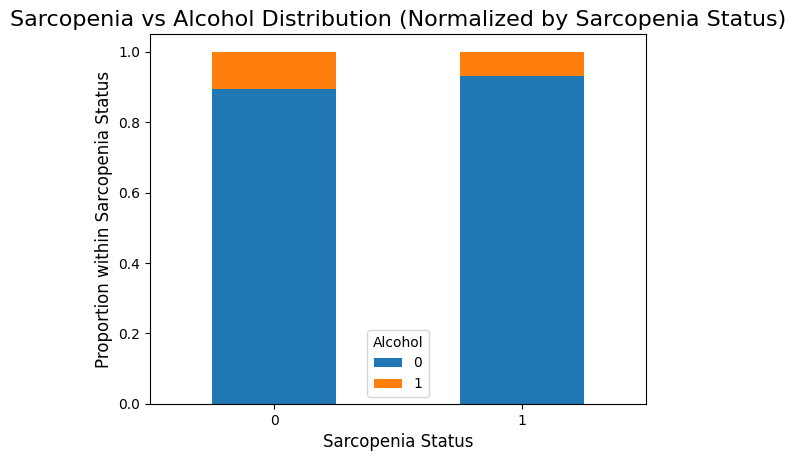

In [ ]:
bivariate_crosstab (df.Sarcopenia,df.Alcohol)

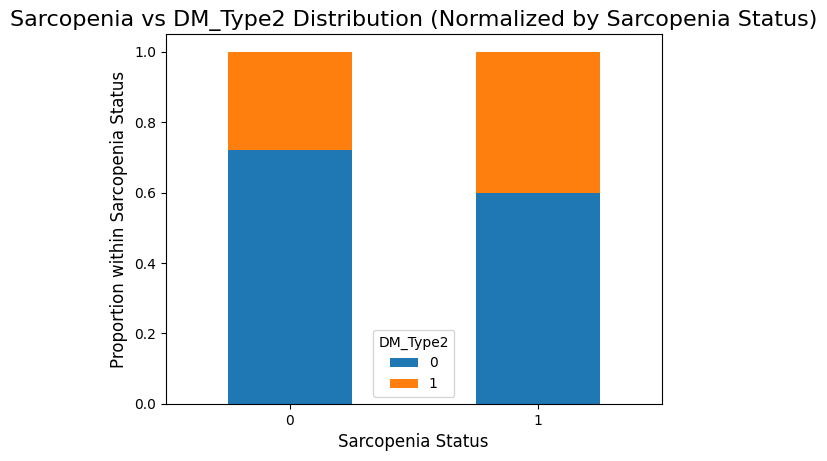

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.DM_Type2)

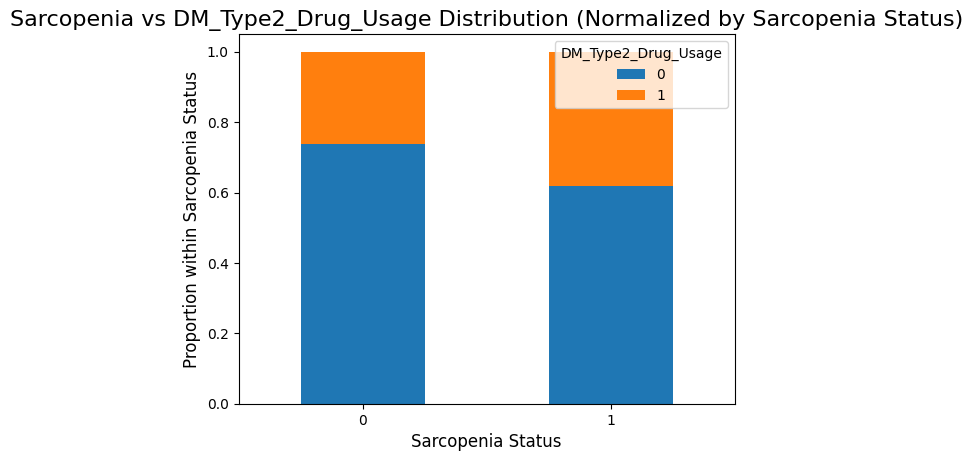

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.DM_Type2_Drug_Usage)

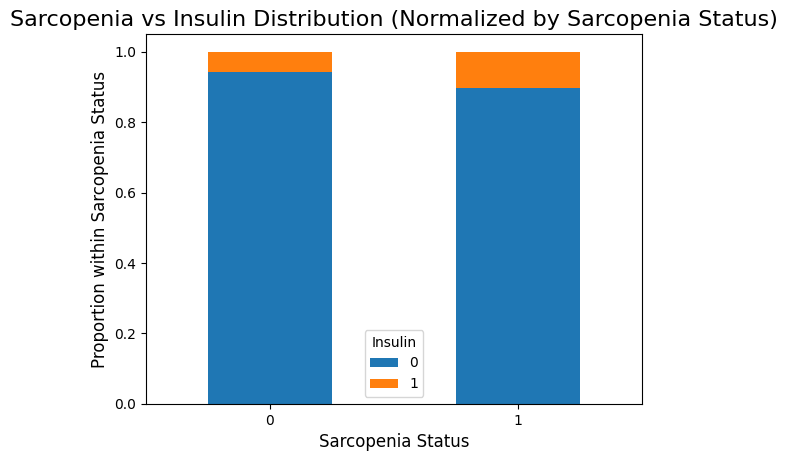

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.Insulin)

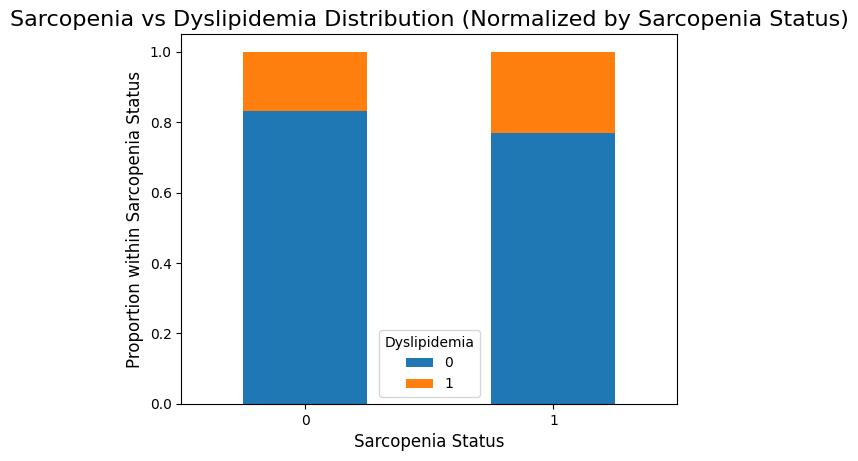

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.Dyslipidemia)

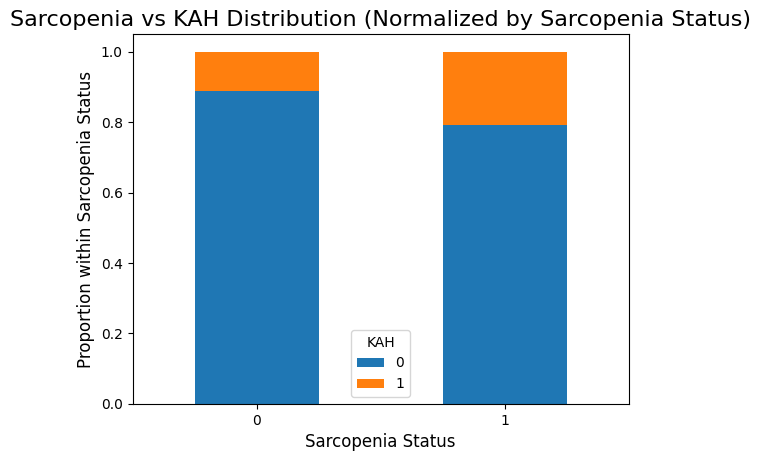

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.KAH)

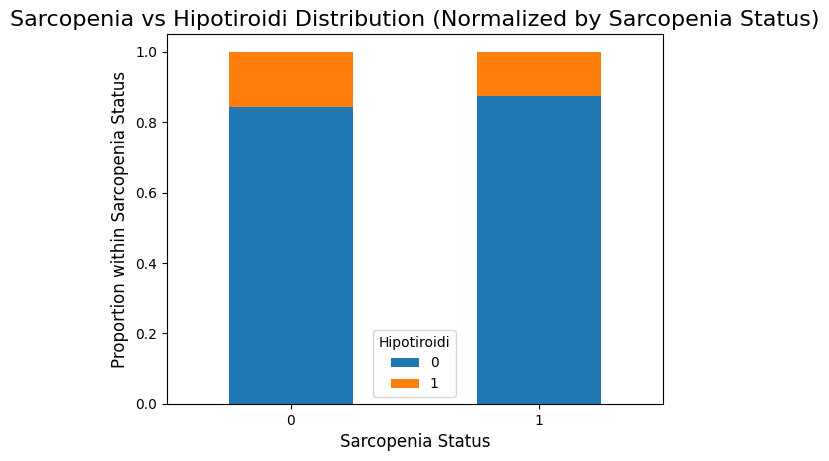

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.Hipotiroidi)

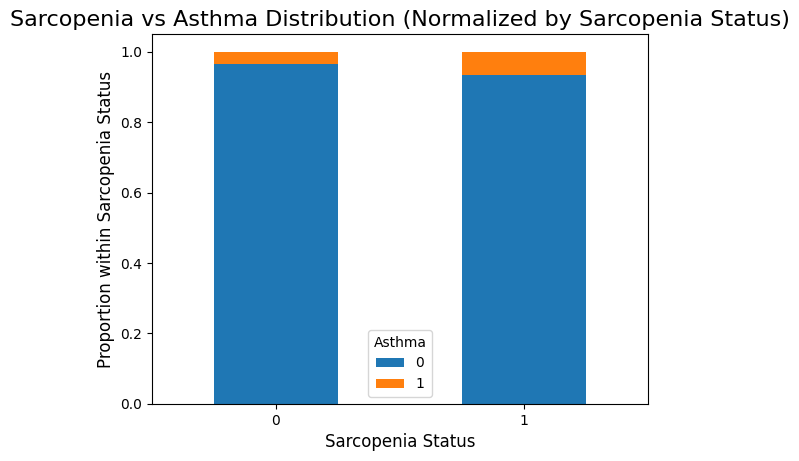

In [ ]:
bivariate_crosstab(df.Sarcopenia,df.Asthma)

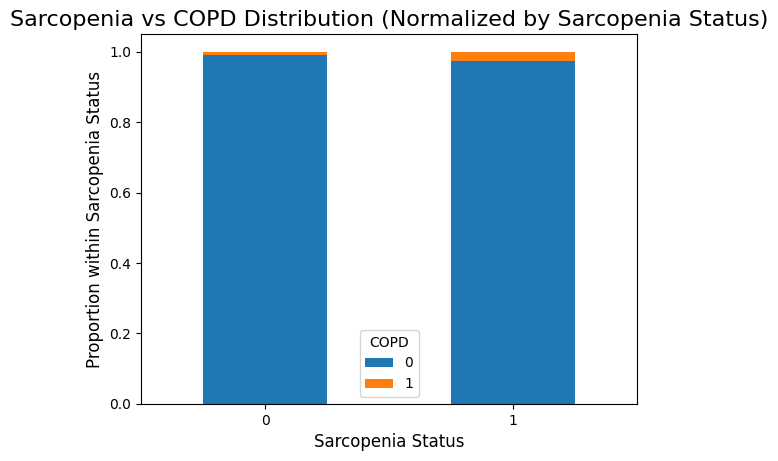

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.COPD)

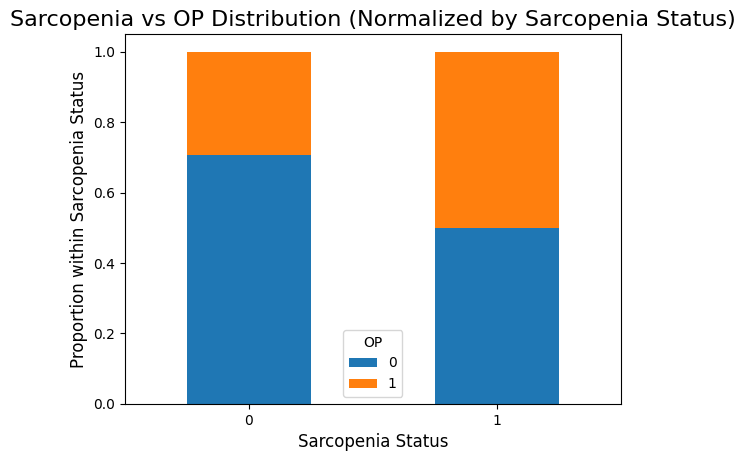

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.OP)

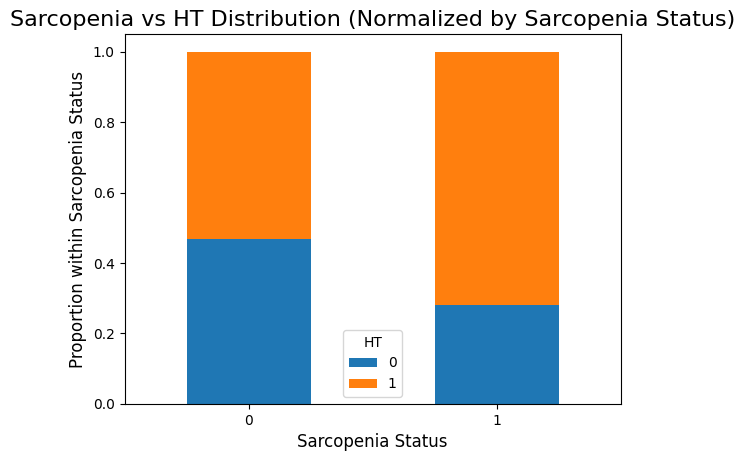

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.HT)

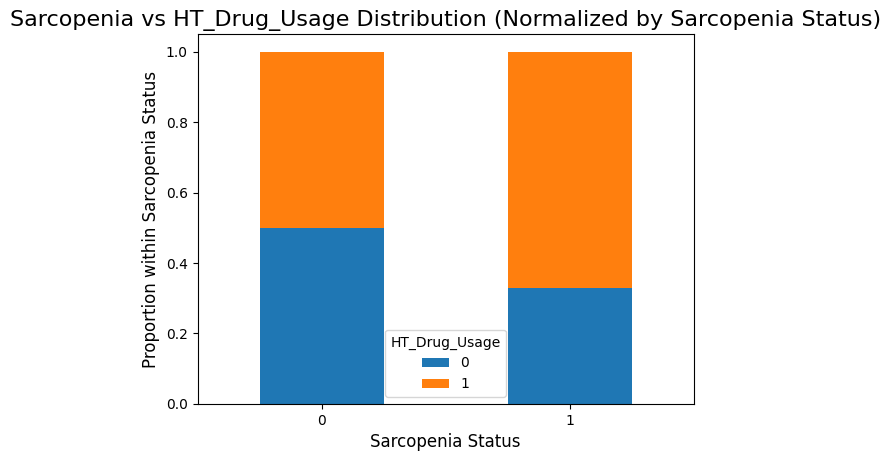

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.HT_Drug_Usage)

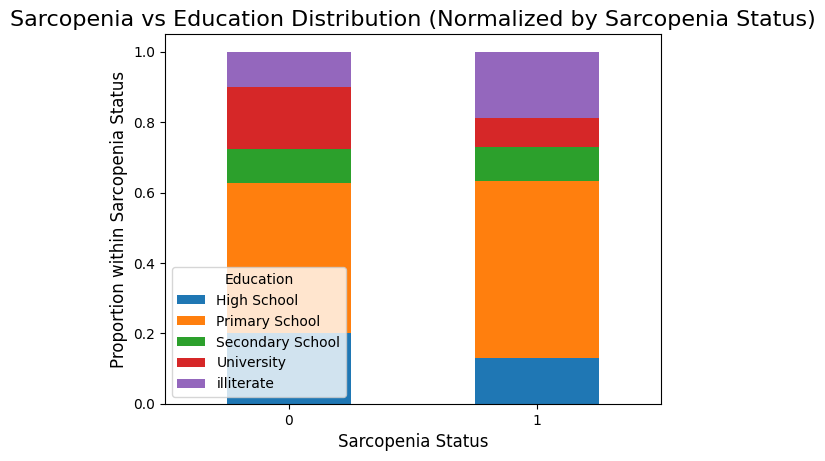

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.Education)

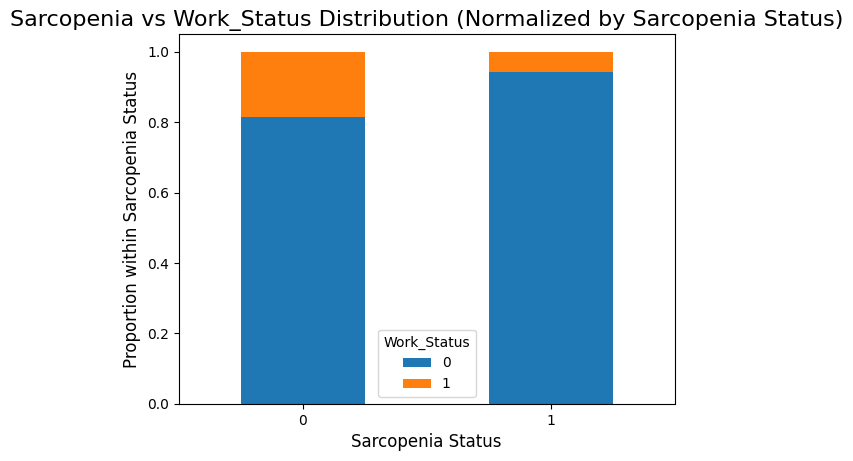

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.Work_Status)

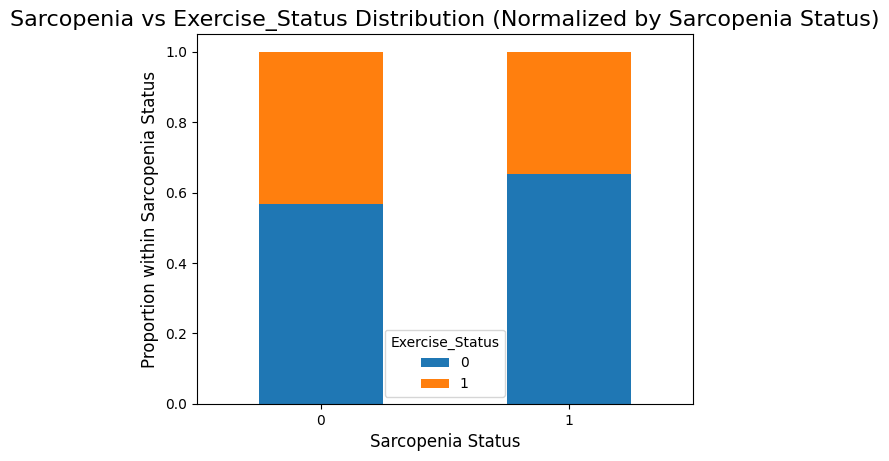

In [ ]:
bivariate_crosstab  (df.Sarcopenia,df.Exercise_Status)

In [ ]:
df.to_excel('/content/drive/MyDrive/SARCOPENIA_PROJECT/sarcopenia-data-set_columns_corrected_2.xlsx')